# Teste técnico da Voxar(Visão Computacional)

##Apresentação do problema

O problema referido se trata de um problema de natureza classificatoria, o dataset trata de tipos de estrada tendo 3 classes(Asphalt, belgian_blocks e offroad) e temos como objetivo criar um modelo para que ele consiga ler uma imagem e classifique o tipo de estrada em um desses 3 tipos. Para quais finalidades isso pode ser útil:

1- Adaptação de coportamento de carros Autonomos:

Poderiamos usar isso para que carro autonomos consigam identificar o tipo da estrada e com isso possaaa usar a configuração do carro que melhor se adeque para o tipo da estrada, por exemplo se Se o sistema detecta que a estrada é offroad, ele deve ajustar o controle de tração, a sensibilidade da frenagem (evitar travar as rodas em terreno irregular), afim de evitar problemas.

2-Otimização de roteamento:

Isso é um ótima funcionalidades para aplicativos de gps como waze ou google maps, visto que o roteador pode sugerir uma rota 2km mais longa, mas que seja 100% asfaltada de maneira a otimizar o tempo do usuário.

3-Inventário de Ativos:

Muitas prefeitura(especialmente nos interiores) não tem um mapa atualizado de quais ruas são asfaltadas ou não, ou seja, uma solução proposta seria que os caminhões de lixo(detém a maior cobertura da cidade) sejam equipados com essa tecnologia afim de auxiliar a prefeitura a identificar as ruas que precisam ser asfaltadas.

##Estudo sobre o Dataset


####Importação das blibliotécas usadas

In [ ]:
#Sistma e manipulação de arquivo
import os
import random
from tqdm import tqdm
from google.colab import files

#Processamento de dados e visualização
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

#Core do pytorch e redes neurais[import torch]
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

#Visão computacional(torchvision)
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler


#métricas e avaliação
from sklearn import metrics
from sklearn.metrics import classification_report

###Funções usada na EDA

####Função para coletar as dimensões das imagens

In [ ]:
def collect_image_dimensions(base_dir):
    widths = []
    heights = []
    aspect_ratios = []
    image_paths = []
    type_file = []

    # percorre pecorrer dentro das pastas para achar todas as imagens
    for root, _, files in os.walk(base_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                image_paths.append(os.path.join(root, file))

    print(f"Coletando dimensões para {len(image_paths)} imagens em {base_dir}...")

    for img_path in image_paths:
        try:
            with Image.open(img_path) as img:
                image_type = img.format
                type_file.append(image_type)
                width, height = img.size
                widths.append(width)
                heights.append(height)
                aspect_ratios.append(width / height)
        except Exception as e:
            print(f"Não foi possível abrir ou processar a imagem {img_path}: {e}")

    return widths, heights, aspect_ratios, type_file


####Função para calcular métricas de cor,brilho, contraste e dimensões de uma imagem

In [ ]:
def calculate_image_metrics(image_path):
    try:
        with Image.open(image_path) as img:
            image_type = img.format
            width, height = img.size

            # Converter para RGB (se não for) e depois para array NumPy
            img_rgb = img.convert('RGB')
            img_np = np.array(img_rgb)

            # Calcular brilho médio (luminosidade): média dos valores de pixels em todos os canais
            brightness = np.mean(img_np)

            # Calcular contraste: desvio padrão dos valores de pixels em todos os canais
            contrast = np.std(img_np)

            # Calcular valores médios dos canais R, G, B
            mean_r = np.mean(img_np[:, :, 0])
            mean_g = np.mean(img_np[:, :, 1])
            mean_b = np.mean(img_np[:, :, 2])

            return brightness, contrast, mean_r, mean_g, mean_b, width, height

    except Exception as e:
        print(f"Erro ao processar a imagem {image_path}: {e}")
        return None, None, None, None, None, None, None


####Função para detectar outliers usando o método dos Inter quartis

In [ ]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound



####Função para dispor as imagens em um grid

In [ ]:
def display_image_grid(image_paths, title, rows, cols):
    plt.figure(figsize=(cols * 4, rows * 4))
    plt.suptitle(title, fontsize=16)
    for i, img_path in enumerate(image_paths):
        plt.subplot(rows, cols, i + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(os.path.basename(img_path), fontsize=8)
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


###Análise Exploratória dos Dados (EDA)


#### 1. Fazer Upload do Arquivo .zip



In [ ]:
print("Por favor, selecione o arquivo .zip do seu dataset para upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print('Arquivo "{name}" com tamanho {length} bytes foi carregado com sucesso.'.format(
      name=fn, length=len(uploaded[fn])))


Por favor, selecione o arquivo .zip do seu dataset para upload:


Saving dataset_Voxar.zip to dataset_Voxar.zip
Arquivo "dataset_Voxar.zip" com tamanho 62922916 bytes foi carregado com sucesso.


#### 2. Descompactar o Dataset

Agora, vamos descompactar o arquivo `.zip`. Certifique-se de substituir `nome_do_seu_dataset.zip` pelo nome real do arquivo que você carregou. Eu assumirei que o nome do arquivo .zip é o primeiro arquivo carregado.

In [ ]:
zip_file_name = list(uploaded.keys())[0]

# Criar uma pasta para o dataset descompactado
# O nome da pasta será o nome do arquivo zip (sem a extensão .zip)
dataset_name = os.path.splitext(zip_file_name)[0]
if not os.path.exists(dataset_name):
    os.makedirs(dataset_name)

# Descompactar o arquivo
!unzip -q "{zip_file_name}" -d "{dataset_name}"

print(f"Dataset '{zip_file_name}' descompactado para a pasta '{dataset_name}'.")
print("Verificando a estrutura de pastas:")
!ls -R "{dataset_name}" # Lista recursivamente o conteúdo da pasta


Dataset 'dataset_Voxar.zip' descompactado para a pasta 'dataset_Voxar'.
Verificando a estrutura de pastas:
dataset_Voxar:
dataset_processed

dataset_Voxar/dataset_processed:
test  train

dataset_Voxar/dataset_processed/test:
asphalt  belgian_blocks  offroad

dataset_Voxar/dataset_processed/test/asphalt:
'07-11_02 (3)_frame_000425.jpg'		   j_ns_af_4_1_002635.jpg
'07-11_02 (3)_frame_000599.jpg'		   j_ns_af_4_1_002715.jpg
'07-11_02 (3)_frame_001773.jpg'		   j_ns_af_4_1_004673.jpg
'07-11_02 (3)_frame_002260.jpg'		   j_ns_af_4_1_008442.jpg
'07-11_02 (3)_frame_003402.jpg'		   j_ns_af_4_1_012667.jpg
'07-11_02 (3)_frame_003717.jpg'		   j_ns_af_4_1_013899.jpg
'07-11_02 (3)_frame_006182.jpg'		   j_ns_af_4_1_018799.jpg
'07-11_02 (3)_frame_006814.jpg'		   j_ns_af_4_1_019268.jpg
'07-11_02 (3)_frame_007540.jpg'		   j_ns_af_5_1_006070.jpg
'07-11_02 (3)_frame_008203.jpg'		   j_ns_af_5_1_009836.jpg
'07-11_02 (3)_frame_009767.jpg'		   j_ns_af_5_1_011323.jpg
'07-11_02 (3)_frame_010139.jpg'		   j_ns_af_5_

#### 3.1 Análise Geométrica das Imagens Originais

Antes de aplicar quaisquer transformações, vamos analisar as dimensões originais das imagens no dataset para entender a distribuição de largura, altura e proporção. Isso nos ajudará a tomar decisões informadas sobre as transformações de `resize` e `crop`.

In [ ]:
# Define o caminho para as pastas de treino e teste dentro do dataset descompactado
# As variáveis dataset_name já estão definidas do passo anterior.
train_dir_full_path = os.path.join(dataset_name, 'dataset_processed', 'train') # Adjusting path based on 'ls -R' output
test_dir_full_path = os.path.join(dataset_name, 'dataset_processed', 'test') # Adjusting path based on 'ls -R' output

# Coleta as dimensões do dataset de treino
train_widths, train_heights, train_aspect_ratios,train_file_type = collect_image_dimensions(train_dir_full_path)

# Coleta as dimensões do dataset de teste
test_widths, test_heights, test_aspect_ratios, test_file_type = collect_image_dimensions(test_dir_full_path)

#Criando um dicionário para dizer quais tipos de arquivo temos no dataset(png,jpeg,etc)
unique_targets_file, counts_file_type = np.unique(train_file_type, return_counts=True)
class_counts_file_type = dict(zip(unique_targets_file, counts_file_type))

print("Contagem de tipos de arquivo de imagem no dataset de treino:")
for class_name_file_type, count in class_counts_file_type.items():
    print(f"  {class_name_file_type} apareceu: {count} vezes")

# Combina as dimensões para uma análise geral
all_widths = train_widths + test_widths
all_heights = train_heights + test_heights
all_aspect_ratios = train_aspect_ratios + test_aspect_ratios

print(f"\nTotal de imagens analisadas: {len(all_widths)}")
print("Estatísticas de Largura:")
print(f"  Mínima: {np.min(all_widths)}, Máxima: {np.max(all_widths)}, Média: {np.mean(all_widths):.2f}, Mediana: {np.median(all_widths)}")
print("Estatísticas de Altura:")
print(f"  Mínima: {np.min(all_heights)}, Máxima: {np.max(all_heights)}, Média: {np.mean(all_heights):.2f}, Mediana: {np.median(all_heights)}")
print("Estatísticas de Proporção (Largura/Altura):")
print(f"  Mínima: {np.min(all_aspect_ratios):.2f}, Máxima: {np.max(all_aspect_ratios):.2f}, Média: {np.mean(all_aspect_ratios):.2f}, Mediana: {np.median(all_aspect_ratios):.2f}")

Coletando dimensões para 900 imagens em dataset_Voxar/dataset_processed/train...
Coletando dimensões para 300 imagens em dataset_Voxar/dataset_processed/test...
Contagem de tipos de arquivo de imagem no dataset de treino:
  JPEG apareceu: 900 vezes

Total de imagens analisadas: 1200
Estatísticas de Largura:
  Mínima: 640, Máxima: 1920, Média: 1801.71, Mediana: 1920.0
Estatísticas de Altura:
  Mínima: 480, Máxima: 1080, Média: 1003.13, Mediana: 1080.0
Estatísticas de Proporção (Largura/Altura):
  Mínima: 1.33, Máxima: 2.55, Média: 1.80, Mediana: 1.78


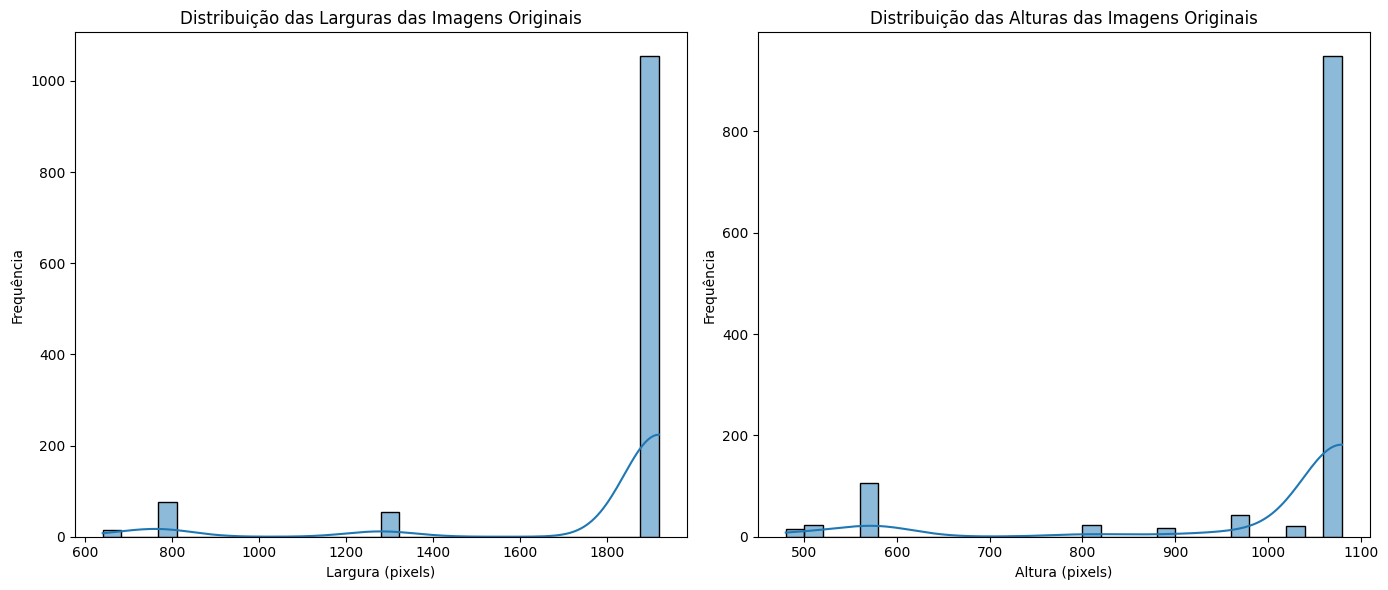

In [ ]:
# Plota histogramas para Largura e Altura
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # 1 linha, 2 colunas, 1º gráfico
sns.histplot(all_widths, bins=30, kde=True)
plt.title('Distribuição das Larguras das Imagens Originais')
plt.xlabel('Largura (pixels)')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2) # 1 linha, 2 colunas, 2º gráfico
sns.histplot(all_heights, bins=30, kde=True)
plt.title('Distribuição das Alturas das Imagens Originais')
plt.xlabel('Altura (pixels)')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

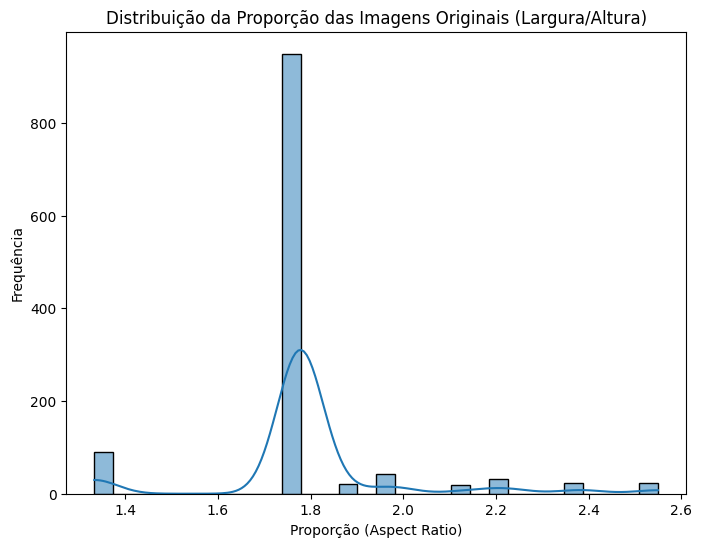


Classificação por Proporção:
  Imagens Verticais (Largura/Altura < 0.9): 0 (0.00%)
  Imagens Quadradas (0.9 <= Largura/Altura <= 1.1): 0 (0.00%)
  Imagens Horizontais (Largura/Altura > 1.1): 1200 (100.00%)


In [ ]:
# Plota histograma para a Proporção (Aspect Ratio)
plt.figure(figsize=(8, 6))
sns.histplot(all_aspect_ratios, bins=30, kde=True)
plt.title('Distribuição da Proporção das Imagens Originais (Largura/Altura)')
plt.xlabel('Proporção (Aspect Ratio)')
plt.ylabel('Frequência')
plt.show()

# Análise das categorias de proporção
vertical_count = sum(1 for ar in all_aspect_ratios if ar < 0.9)
square_count = sum(1 for ar in all_aspect_ratios if 0.9 <= ar <= 1.1)
horizontal_count = sum(1 for ar in all_aspect_ratios if ar > 1.1)

total_images = len(all_aspect_ratios)

print("\nClassificação por Proporção:")
print(f"  Imagens Verticais (Largura/Altura < 0.9): {vertical_count} ({vertical_count/total_images:.2%})")
print(f"  Imagens Quadradas (0.9 <= Largura/Altura <= 1.1): {square_count} ({square_count/total_images:.2%})")
print(f"  Imagens Horizontais (Largura/Altura > 1.1): {horizontal_count} ({horizontal_count/total_images:.2%})")

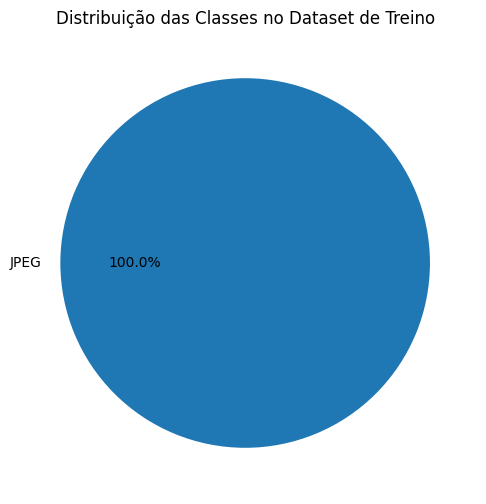

In [ ]:
#Gráfico de Pizza para ve quais os tipos de arquivos estamos lidando.
plt.figure(figsize=(6,6))
plt.pie(class_counts_file_type.values(), labels=class_counts_file_type.keys(), autopct='%1.1f%%')
plt.title('Distribuição das Classes no Dataset de Treino')
plt.show()

#### 3. Carregar o Dataset Usando `torchvision.datasets.ImageFolder`

Vamos definir as transformações e carregar os datasets de treino e teste.

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((384, 384)), # Redimensiona todas as imagens para 384x384 para reter mais detalhes
    transforms.RandomHorizontalFlip(), # Aumenta o dataset horizontalmente
    transforms.ToTensor(), # Converte a imagem para um tensor PyTorch
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normaliza
])

transform_test = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Carrega os datasets usando ImageFolder
try:
    train_dataset = datasets.ImageFolder(train_dir_full_path, transform=transform_train)
    test_dataset = datasets.ImageFolder(test_dir_full_path, transform=transform_test)

    print(f"Número de imagens de treino: {len(train_dataset)}")
    print(f"Número de imagens de teste: {len(test_dataset)}")
    print(f"Classes encontradas: {train_dataset.classes}")

    # Cria DataLoaders
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"\nPrimeiro batch do DataLoader de treino: {next(iter(train_loader))[0].shape}")

except Exception as e:
    print(f"Erro ao carregar o dataset com ImageFolder: {e}")
    print("Verifique se a estrutura de pastas está correta (ex: seu_dataset/dataset_processed/train/classe1/img.jpg).")
    print("Caminho do diretório de treino esperado:", train_dir_full_path)
    print("Caminho do diretório de teste esperado:", test_dir_full_path)

Número de imagens de treino: 900
Número de imagens de teste: 300
Classes encontradas: ['asphalt', 'belgian_blocks', 'offroad']

Primeiro batch do DataLoader de treino: torch.Size([32, 3, 384, 384])


In [ ]:
# Obter os nomes das classes e transforma-las em valores numéricos para contagem
class_names = train_dataset.classes
class_targets = train_dataset.targets

# Contar o número de ocorrências de cada classe
unique_targets, counts = np.unique(class_targets, return_counts=True)
class_counts = dict(zip([class_names[t] for t in unique_targets], counts))

print("Contagem de imagens por classe no dataset de treino:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count} imagens")

Contagem de imagens por classe no dataset de treino:
  asphalt: 655 imagens
  belgian_blocks: 94 imagens
  offroad: 151 imagens


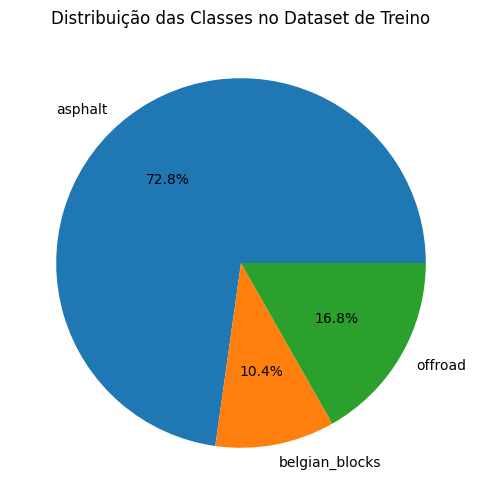

In [ ]:
#Criação de um gráfico para melhor vizualização das distribuições das classes
plt.figure(figsize=(6,6))
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%')
plt.title('Distribuição das Classes no Dataset de Treino')
plt.show()


#### 3.2 Análise de Cores, Brilho e Contraste das Imagens

In [ ]:
# Coletar dados para todas as imagens nos conjuntos de treino e teste
image_metrics_data = []

# Processar imagens do conjunto de treino
for img_path, class_idx in tqdm(train_dataset.samples, desc="Processando imagens de treino para métricas"):
    brightness, contrast, mean_r, mean_g, mean_b, width, height = calculate_image_metrics(img_path)
    if brightness is not None:
        image_metrics_data.append({
            'path': img_path,
            'class': class_names[class_idx],
            'brightness': brightness,
            'contrast': contrast,
            'mean_r': mean_r,
            'mean_g': mean_g,
            'mean_b': mean_b,
            'width': width,
            'height': height
        })

# Processar imagens do conjunto de teste
for img_path, class_idx in tqdm(test_dataset.samples, desc="Processando imagens de teste para métricas"):
    brightness, contrast, mean_r, mean_g, mean_b, width, height = calculate_image_metrics(img_path)
    if brightness is not None:
        image_metrics_data.append({
            'path': img_path,
            'class': class_names[class_idx],
            'brightness': brightness,
            'contrast': contrast,
            'mean_r': mean_r,
            'mean_g': mean_g,
            'mean_b': mean_b,
            'width': width,
            'height': height
        })

# Criar um DataFrame com as métricas coletadas
metrics_df = pd.DataFrame(image_metrics_data)

print("Métricas de imagem coletadas com sucesso.")
display(metrics_df.head())

Processando imagens de teste para métricas: 100%|██████████| 300/300 [00:14<00:00, 20.56it/s]

Métricas de imagem coletadas com sucesso.


,path,class,brightness,contrast,mean_r,mean_g,mean_b,width,height
0,dataset_Voxar/dataset_processed/train/asphalt/...,asphalt,15.213914,39.534579,15.046323,14.903223,15.692197,1920,1080
1,dataset_Voxar/dataset_processed/train/asphalt/...,asphalt,25.465457,28.010651,24.373152,25.758772,26.264445,1920,1080
2,dataset_Voxar/dataset_processed/train/asphalt/...,asphalt,15.198345,27.736929,17.747497,13.802657,14.044881,1920,1080
3,dataset_Voxar/dataset_processed/train/asphalt/...,asphalt,16.245117,28.106508,21.663493,15.092273,11.979584,1920,1080
4,dataset_Voxar/dataset_processed/train/asphalt/...,asphalt,26.092138,55.781715,27.698160,26.274936,24.303317,1920,1080


#### 3.2.1 Distribuição de Brilho por Classe

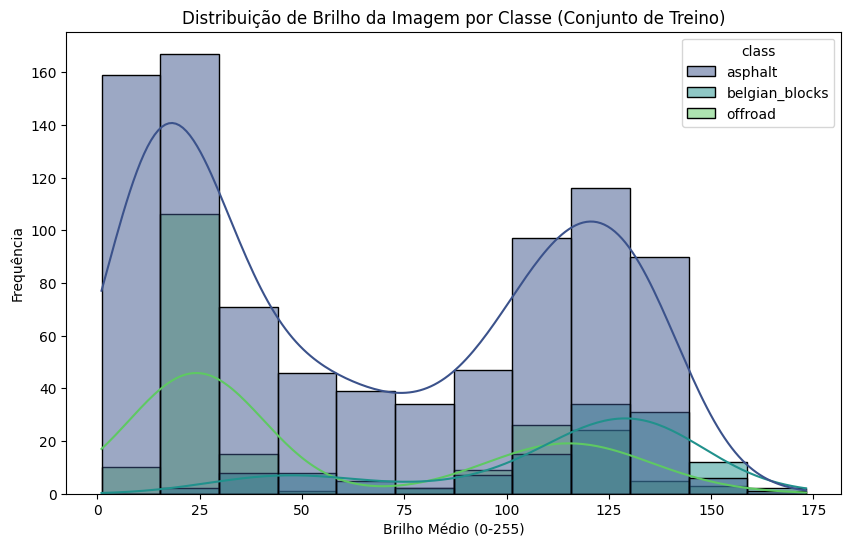

In [ ]:
# Plotar a Distribuição de Brilho
plt.figure(figsize=(10, 6))
sns.histplot(data=metrics_df, x='brightness', hue='class', kde=True, palette='viridis')
plt.title('Distribuição de Brilho da Imagem por Classe (Conjunto de Treino)')
plt.xlabel('Brilho Médio (0-255)')
plt.ylabel('Frequência')
plt.show()

#### 3.2.2 Distribuição de Contraste por Classe

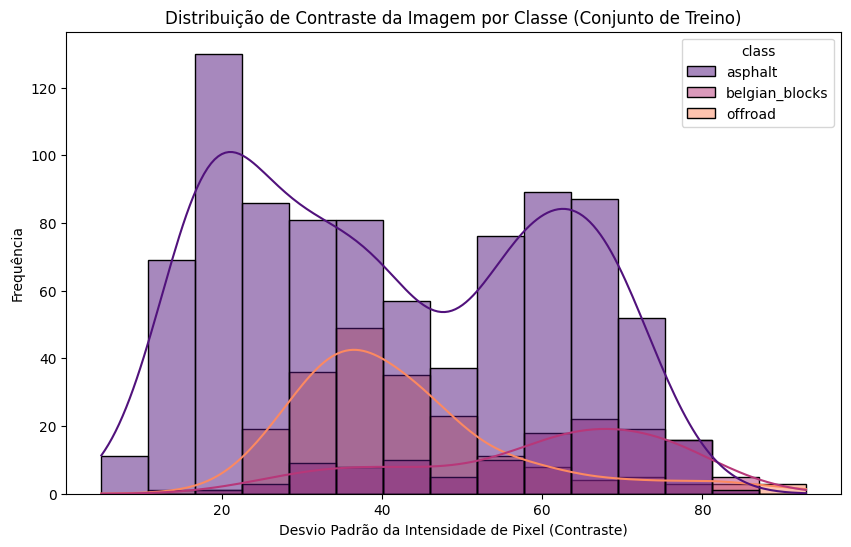

In [ ]:
# Plotar a Distribuição de Contraste
plt.figure(figsize=(10, 6))
sns.histplot(data=metrics_df, x='contrast', hue='class', kde=True, palette='magma')
plt.title('Distribuição de Contraste da Imagem por Classe (Conjunto de Treino)')
plt.xlabel('Desvio Padrão da Intensidade de Pixel (Contraste)')
plt.ylabel('Frequência')
plt.show()

#### 3.2.3 Distribuição dos Canais de Cor (RGB) por Classe

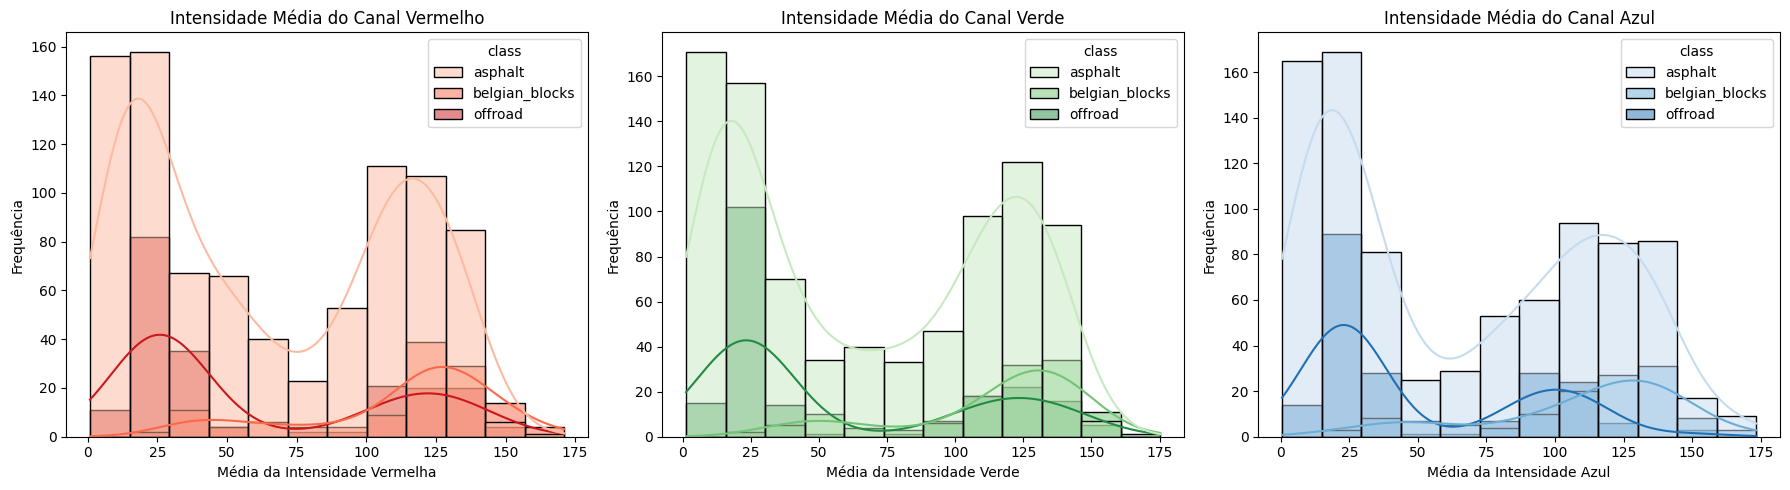

In [ ]:
# Plotar a Distribuição dos valores médios de RGB
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(data=metrics_df, x='mean_r', hue='class', kde=True, palette='Reds')
plt.title('Intensidade Média do Canal Vermelho')
plt.xlabel('Média da Intensidade Vermelha')
plt.ylabel('Frequência')

plt.subplot(1, 3, 2)
sns.histplot(data=metrics_df, x='mean_g', hue='class', kde=True, palette='Greens')
plt.title('Intensidade Média do Canal Verde')
plt.xlabel('Média da Intensidade Verde')
plt.ylabel('Frequência')

plt.subplot(1, 3, 3)
sns.histplot(data=metrics_df, x='mean_b', hue='class', kde=True, palette='Blues')
plt.title('Intensidade Média do Canal Azul')
plt.xlabel('Média da Intensidade Azul')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

#### 3.3 Visualização de Amostras de Imagens por Classe

In [ ]:
# Coletar 5 amostras aleatórias de cada classe
samples_per_class = 5
images_to_display = []

for class_name in class_names:
    class_df = metrics_df[metrics_df['class'] == class_name]
    #Garantir que não tentemos amostrar mais imagens do que as disponíveis
    num_samples = min(samples_per_class, len(class_df))
    if num_samples > 0:
        sample_paths = random.sample(class_df['path'].tolist(), num_samples)
        images_to_display.extend(sample_paths)

display_image_grid(images_to_display, '5 Amostras Aleatórias por Classe', len(class_names), samples_per_class)

#Por ser um dataset de dados sensíveis vou limpar a saída, mas esse código dispõe 5 imagens de cada classe

#### 3.4 Visualização de Imagens com Resoluções Extremas

In [ ]:
# Imagens com maior e menor largura
min_width_img_path = metrics_df.loc[metrics_df['width'].idxmin()]['path']
max_width_img_path = metrics_df.loc[metrics_df['width'].idxmax()]['path']

# Imagens com maior e menor altura
min_height_img_path = metrics_df.loc[metrics_df['height'].idxmin()]['path']
max_height_img_path = metrics_df.loc[metrics_df['height'].idxmax()]['path']

extreme_resolution_paths = [
    min_width_img_path, max_width_img_path,
    min_height_img_path, max_height_img_path
]

extreme_resolution_titles = [
    f"Menor Largura ({metrics_df['width'].min()}px)",
    f"Maior Largura ({metrics_df['width'].max()}px)",
    f"Menor Altura ({metrics_df['height'].min()}px)",
    f"Maior Altura ({metrics_df['height'].max()}px)"
]

plt.figure(figsize=(15, 8))
plt.suptitle('Imagens com Resoluções Extremas', fontsize=16)

for i, img_path in enumerate(extreme_resolution_paths):
    plt.subplot(2, 2, i + 1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"{extreme_resolution_titles[i]}\n({os.path.basename(img_path)})", fontsize=10)
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#Por ser um dataset de dados sensíveis vou limpar a saída, mas esse código dispõe as imagens de maior resolução e menor resolução.

#### 3.5 Visualização de Imagens com Brilho Extremo

In [ ]:
# Imagens com maior e menor brilho
min_brightness_img_path = metrics_df.loc[metrics_df['brightness'].idxmin()]['path']
max_brightness_img_path = metrics_df.loc[metrics_df['brightness'].idxmax()]['path']

extreme_brightness_paths = [min_brightness_img_path, max_brightness_img_path]

extreme_brightness_titles = [
    f"Menor Brilho ({metrics_df['brightness'].min():.2f})",
    f"Maior Brilho ({metrics_df['brightness'].max():.2f})"
]

plt.figure(figsize=(10, 5))
plt.suptitle('Imagens com Brilho Extremo', fontsize=16)

for i, img_path in enumerate(extreme_brightness_paths):
    plt.subplot(1, 2, i + 1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"{extreme_brightness_titles[i]}\n({os.path.basename(img_path)})", fontsize=10)
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#Por ser um dataset de dados sensíveis vou limpar a saída, mas esse código dispõe as imagens com o maior x o menor brilho.

#### 3.6 Identificação de Outliers por Método Estatístico (IQR)

In [ ]:
# Métricas para verificar outliers
metrics_to_check = ['brightness', 'contrast', 'width', 'height']

all_outlier_images = pd.DataFrame()

print("Detectando outliers nas seguintes métricas usando o método IQR:")
for metric in metrics_to_check:
    outliers_df, lower_bound, upper_bound = detect_outliers_iqr(metrics_df, metric)
    if not outliers_df.empty:
        print(f"  - Métrica '{metric}': {len(outliers_df)} outliers encontrados (Limite Inferior: {lower_bound:.2f}, Limite Superior: {upper_bound:.2f})")
        # Adicionar uma coluna indicando por qual métrica a imagem é um outlier
        outliers_df['outlier_metric'] = metric
        all_outlier_images = pd.concat([all_outlier_images, outliers_df])
    else:
        print(f"  - Métrica '{metric}': Nenhum outlier encontrado.")

# Remover duplicatas, pois uma imagem pode ser outlier em múltiplas métricas
all_outlier_images = all_outlier_images.drop_duplicates(subset=['path']).reset_index(drop=True)

print(f"\nTotal de imagens identificadas como potenciais outliers: {len(all_outlier_images)}")
display(all_outlier_images.head())


Detectando outliers nas seguintes métricas usando o método IQR:
  - Métrica 'brightness': Nenhum outlier encontrado.
  - Métrica 'contrast': Nenhum outlier encontrado.
  - Métrica 'width': 146 outliers encontrados (Limite Inferior: 1920.00, Limite Superior: 1920.00)
  - Métrica 'height': 252 outliers encontrados (Limite Inferior: 1080.00, Limite Superior: 1080.00)

Total de imagens identificadas como potenciais outliers: 252


/tmp/ipykernel_4743/2200108669.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_df['outlier_metric'] = metric
/tmp/ipykernel_4743/2200108669.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_df['outlier_metric'] = metric


,path,class,brightness,contrast,mean_r,mean_g,mean_b,width,height,outlier_metric
0,dataset_Voxar/dataset_processed/train/asphalt/...,asphalt,54.334845,37.777230,60.825597,55.323631,46.855307,1280,576,width
1,dataset_Voxar/dataset_processed/train/asphalt/...,asphalt,58.160257,32.778700,62.336034,59.335010,52.809726,1280,576,width
2,dataset_Voxar/dataset_processed/train/asphalt/...,asphalt,47.645349,38.406281,53.689802,47.590371,41.655874,1280,576,width
3,dataset_Voxar/dataset_processed/train/asphalt/...,asphalt,41.043688,36.032688,48.119093,41.188403,33.823566,1280,576,width
4,dataset_Voxar/dataset_processed/train/asphalt/...,asphalt,53.481027,32.081734,60.693922,54.640978,45.108181,1280,576,width


#### 3.7 Visualização de Amostras de Outliers Identificados

Vamos exibir algumas das imagens identificadas como potenciais outliers para uma inspeção visual.

In [ ]:
if not all_outlier_images.empty:
    # Selecionar até 10 imagens aleatórias dos outliers para visualização
    num_samples_to_show = min(15, len(all_outlier_images))
    sample_outlier_paths = random.sample(all_outlier_images['path'].tolist(), num_samples_to_show)

    plt.figure(figsize=(num_samples_to_show * 3, 5))
    plt.suptitle('Amostras de Imagens Identificadas como Outliers (IQR)', fontsize=16)

    for i, img_path in enumerate(sample_outlier_paths):
        plt.subplot(1, num_samples_to_show, i + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        # Encontrar a métrica que classificou esta imagem como outlier para o título
        outlier_info = all_outlier_images[all_outlier_images['path'] == img_path].iloc[0]
        title_text = f"{os.path.basename(img_path)}\n(Outlier por: {outlier_info['outlier_metric']})"
        plt.title(title_text, fontsize=8)
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("Nenhuma imagem identificada como outlier pelo método IQR para visualização.")

#Por ser um dataset de dados sensíveis vou limpar a saída, mas esse código dispõe 10 imagens classificadas como outliers


##Conclusões sobre a EDA

Por meio do EDA feito sobre o dataset, podemos concluir algumas coisas como:


**-** Nosso dataset é dividido em 3 tipos de classes targets(asplhat, offroad e belgian_blocks), sendo as 3 classes distribuídas de forma extremamente desbalanceada, sendo no total 900 features para treino de modo que temos 655 imagens do tipo asphalt(72,8% do dataset), 151 do tipo offroad(16,8% do dataset) e 94 do tipo belgian_blocks (10,4% do dataset) e isso pode ser um grande problema para a continuidade do projeto, visto que um dataset desbalanceado pode gerar overfitting, ou seja, o modelo se ajustaria aos dados do treino e não aprenderia, já que se uma classe representa mais de 70% se o modelo apenas chutar sempre essa classe ele estaria acertando mais que 70% das vezes. Para o tratamento do desbalanceamento estou pensando em duas hipóteses, a primeira se trata de usar oversampling, ou seja isso fará com que as imagens das classes menores apareçam com mais frequência em cada época assim dando uma equilibrada no desbalanceamento. Já minha segunda solução seria atribuir pesos para as classes, dessa forma as classes minoritárias teriam pesos maiores, ou seja, se o modelo erra a classe minoritária ele seria penalizado de maneira mais rígida e dessa forma o modelo vai ser erforça mais para reduzir os erros das classes minoritárias, assim reduzindo a chance do modelo de apenas chutar a classe majoritária.


**-** Foi verificado também que todas as features estão em apensa um único tipo(JPEG), não que isso mude muita coisa, mas so para questão analítica.


**-** Foi feita a análise das dimensões das imagens também para que seja feita posteriormente a normalização das imagens e foi constatado que a maioria das imagens estão na dimensionalidade de 1800x1100 ou proporção de 1.8, com isso temos que tomar cuidado ao mudar a resolução da imagem para não termos perca de informações(farei alguns teste com 384X384, 512x512 e até 600x600), foi informado também as descrição:

Estatísticas de Largura:
 Mínima: 640, Máxima: 1920, Média: 1801.71, Mediana: 1920.0

Estatísticas de Altura:
 Mínima: 480, Máxima: 1080, Média: 1003.13, Mediana: 1080.0

Estatísticas de Proporção (Largura/Altura):
 Mínima: 1.33, Máxima: 2.55, Média: 1.80, Mediana: 1.78



**-** Também foram feitas análises de cores, brilhos e contrastes nas imagens afim de procurar alguns padrões, dessa maneira concluimos que O Brilho é uma Métrica "Mentirosa". A Descoberta: Os gráficos mostram comportamento bimodal, revelando que as estradas asphalt estão bem distribuídas e todos os tipos de brilhos, enquanto a offroad está em brilhos mais altos, o que poderia levar a hipótese que as imagens offroads poderiam ter um padrão de serem tiradas durante o dia, enquanto as asphalts terem fotos de dias e de noite, mas ao ir mais afundo ao visualizar as imagens da offroad(mais de uma vez foram pego aleatoriamente grupos de 5 imagens) vimos que se predominava as fotos de noite, mas o seu brilho é classificado como alto não por causa do sol, mas sim por uma presença de uma luz muito forte(farol) em um fundo escuro(a estrada sem iluminação a noite) demonstrando sim que o brilho é uma métrica mentirosa. Diferente do contastre que é sim uma boa métrica de diferenciação, visto que:

Asphalt (Roxo): Tem uma distribuição de contraste muito larga. Isso acontece porque o asfalto liso tem baixo contraste, mas o asfalto molhado com reflexos gera picos de contraste altíssimos.

Offroad (Laranja): O contraste é mais "comportado" e centralizado.

Belgian Blocks (Rosa): Veja como o pico de contraste dela é ligeiramente deslocado para a direita (~65-70) em comparação ao primeiro pico do asfalto. Isso faz sentido: paralelepípedos têm frestas pretas entre pedras claras, gerando naturalmente mais contraste local do que um asfalto liso.

ou seja cada tipo tem contrastes diferente oq pode talvez ser usado para contribuir na classificação do tipo de solo.


**-** Posteriormente foram feita buscas por outliers e foi usado o metódo dos quartis partindo como paramêtros as métricas de brilho, contraste, largura e altura das imagens e com isso so achamos outliers quando se trata de largura ou altura e essa imagens não são de fato outliers visto que as imagens não estavam em proporções muito fora do padrão, isso ocorreu apenas por termos um dataset bastante homogeneo quando se trata dessas métricas e qualquer coisa que fuja um pouco disso seria classificado como outlier, mesmo sendo uma boa imagem com informações úteis. A tentativa principal da busca dos outliers era ve se o brilho e o contraste podiam contribuir para que deixasse a pista desfocada e sem chance de ser classificada ou com muita dificuldade para classificar até para o olho humano, oq não foi comprovado, mas ao olhar algumas imagens **(como a (07-11-02 (3)_frame_005814.jpg(a imagem de maior altura do dataset)))** ao olho nu verifiquei que é possível que tenhamos outliers no dataset e que o principal responsável disso seriam as condições temporais como chuva, oq não fui capaz de achar uma solução para filtrar as imagens por condição temporal visto que não temos uma coluna "tempo".

**-** Por fim o próximo passe será testar diversos tipos de hipóteses para vê qual obtém o melhor resultado, provavelmente o algoritmo escolhido será uma Convolutional Neural Network(CNN) e testarei com os dados balanceados, os dados não balanceados, treinando uma rede do zero, usando uma rede ja treinada e como no EDA foi visto que o contraste possa ter um papel importante na classificação, a rede neural que tiver o melhor resultado vou testar passando para ela antes da última camada de classificação os valores do contraste da imagem com os dados que vieram da imagem para verificar se teremos um resultado melhor!

##Funções Gerais das redes neurais

###Função de treinamento

In [ ]:
#Essa função é responsável pelo treinamento da nossa rede
def train_model(model, criterion, optimizer, train_loader, device):
    model.train() # Coloca o modelo em modo de treinamento
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for inputs, labels in tqdm(train_loader, desc="Treinando"): # Use tqdm para barra de progresso
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zera os gradientes do otimizador

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward() # Calcula os gradientes descendente
        optimizer.step() # Atualiza os pesos do modelo

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_predictions / total_predictions
    return epoch_loss, epoch_acc

###Função de avaliação

In [ ]:
#Esta função irá avaliar o desempenho do modelo no conjunto de teste,
#calculando a perda e a acurácia sem atualizar os pesos do modelo.
def evaluate_model(model, criterion, test_loader, device):
    model.eval() # Coloca o modelo em modo de avaliação (desativa dropout e batch norm)
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    all_labels = [] # Lista para armazenar todos os rótulos verdadeiros
    all_predictions = [] # Lista para armazenar todas as previsões do modelo

    with torch.no_grad(): # Desativa o cálculo de gradientes para economia de memória e velocidade
        for inputs, labels in tqdm(test_loader, desc="Avaliando"):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    epoch_loss = running_loss / len(test_loader.dataset)
    epoch_acc = correct_predictions / total_predictions
    return epoch_loss, epoch_acc, all_labels, all_predictions # Retorna as listas de rótulos e previsões

###Contar o número aparições de cada classe

In [ ]:
def count_class_occurrences(dataset):
  #Pegar os índices de cada classe
  class_targets = dataset.targets
  #Conta o número de ocorrência de cada classe
  unique_targets, counts = np.unique(class_targets, return_counts=True)
  class_counts_list = counts.tolist() # Converte numpy array para lista
  total_samples = len(class_targets)
  return class_counts_list, total_samples

###Loop principal CNN do zero

In [ ]:
def principal_loop_trainning(num_epochs, model, criterion, optimizer, train_loader, model_name="Modelo"):

  all_train_losses_runs = []
  all_train_accuracies_runs = []
  all_test_losses_runs = []
  all_test_accuracies_runs = []

  # Variables to store the history of the LAST run for the table/summary
  final_run_train_losses = []
  final_run_train_accuracies = []
  final_run_test_losses = []
  final_run_test_accuracies = []

  for i in range(10):
    print(f"Treino ({model_name}): {i+1}/10\n")

    current_run_train_losses = []
    current_run_train_accuracies = []
    current_run_test_losses = []
    current_run_test_accuracies = []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs} ({model_name})")

        train_loss, train_acc = train_model(model, criterion, optimizer, train_loader, device)
        current_run_train_losses.append(train_loss)
        current_run_train_accuracies.append(train_acc)
        print(f"  Treino ({model_name}) -> Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")

        test_loss, test_acc, _, _ = evaluate_model(model, criterion, test_loader, device)
        current_run_test_losses.append(test_loss)
        current_run_test_accuracies.append(test_acc)
        print(f"  Teste  ({model_name}) -> Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    all_train_losses_runs.append(current_run_train_losses)
    all_train_accuracies_runs.append(current_run_train_accuracies)
    all_test_losses_runs.append(current_run_test_losses)
    all_test_accuracies_runs.append(current_run_test_accuracies)

    # Store the history of the last run
    if i == 9:
        final_run_train_losses = current_run_train_losses
        final_run_train_accuracies = current_run_train_accuracies
        final_run_test_losses = current_run_test_losses
        final_run_test_accuracies = current_run_test_accuracies

  print(f"\nTreinamento da {model_name} concluído!")

  return (all_train_losses_runs, all_train_accuracies_runs,
          all_test_losses_runs, all_test_accuracies_runs,
          final_run_train_losses, final_run_train_accuracies,
          final_run_test_losses, final_run_test_accuracies)

###Loop principal da CNN Pré treinada

In [ ]:
def principal_loop_cnn_pre_trained(num_epochs):
  all_train_losses_runs = []
  all_train_accuracies_runs = []
  all_test_losses_runs = []
  all_test_accuracies_runs = []

  # Variables to store the history of the LAST run for the table/summary
  final_run_train_losses = []
  final_run_train_accuracies = []
  final_run_test_losses = []
  final_run_test_accuracies = []

  #Foi criado o loop de range 15 para termos noção do real aproveiamento do modelo
  #Visto que redes neurais são modelos estocásticos ou não determinístico, ou seja,
  #A cada rodada o resultado pode mudar(isso serve para dar mais credibilidade ao resultado)
  for i in range(10):
    print(f"Treino: {i+1}/10")
    current_run_train_losses = []
    current_run_train_accuracies = []
    current_run_test_losses = []
    current_run_test_accuracies = []
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # Treinar o modelo
        train_loss, train_acc = train_model(model, criterion, optimizer, train_loader, device)
        current_run_train_losses.append(train_loss)
        current_run_train_accuracies.append(train_acc)
        print(f"  Treino -> Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")

        # Avaliar o modelo
        test_loss, test_acc, _, _ = evaluate_model(model, criterion, test_loader, device) # Agora desempacota os 4 valores
        current_run_test_losses.append(test_loss)
        current_run_test_accuracies.append(test_acc)
        print(f"  Teste  -> Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    all_train_losses_runs.append(current_run_train_losses)
    all_train_accuracies_runs.append(current_run_train_accuracies)
    all_test_losses_runs.append(current_run_test_losses)
    all_test_accuracies_runs.append(current_run_test_accuracies)

    # Store the history of the last run
    if i == 9:
        final_run_train_losses = current_run_train_losses
        final_run_train_accuracies = current_run_train_accuracies
        final_run_test_losses = current_run_test_losses
        final_run_test_accuracies = current_run_test_accuracies

  print("\nTreinamento concluído!")

  return (all_train_losses_runs, all_train_accuracies_runs,
          all_test_losses_runs, all_test_accuracies_runs,
          final_run_train_losses, final_run_train_accuracies,
          final_run_test_losses, final_run_test_accuracies)

###Função para visualização do histórico do treinamento

In [ ]:
def train_historic_visualization(all_train_losses_runs,all_train_accuracies_runs,all_test_losses_runs,all_test_accuracies_runs,num_epochs):
  # Calcular as médias das perdas e acurácias ao longo das 15 execuções
  avg_train_losses = np.mean(all_train_losses_runs, axis=0)
  avg_train_accuracies = np.mean(all_train_accuracies_runs, axis=0)
  avg_test_losses = np.mean(all_test_losses_runs, axis=0)
  avg_test_accuracies = np.mean(all_test_accuracies_runs, axis=0)

  plt.figure(figsize=(12, 5))

  plt.subplot(1, 2, 1)
  plt.plot(range(1, num_epochs + 1), avg_train_losses, label='Treino Loss Médio')
  plt.plot(range(1, num_epochs + 1), avg_test_losses, label='Teste Loss Médio')
  plt.title('Curva de Perda (Loss)')
  plt.xlabel('Época')
  plt.ylabel('Loss')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(range(1, num_epochs + 1), avg_train_accuracies, label='Treino Acc Médio')
  plt.plot(range(1, num_epochs + 1), avg_test_accuracies, label='Teste Acc Médio')
  plt.title('Curva de Acurácia (Accuracy)')
  plt.xlabel('Época')
  plt.ylabel('Acurácia')
  plt.legend()

  plt.tight_layout()
  plt.show()

###Função para criar matriz de confusão e relatório de classificação

In [ ]:
def results(model_to_evaluate, criterion_to_evaluate, test_loader_to_evaluate, device_to_evaluate, class_names_to_evaluate, model_description_for_title="Modelo Final"):
    # Para a matriz de confusão do modelo final, avaliamos o modelo uma última vez para coletar todos os rótulos e previsões.
    _, _, true_labels, predicted_labels = evaluate_model(model_to_evaluate, criterion_to_evaluate, test_loader_to_evaluate, device_to_evaluate)

    # Gerar a matriz de confusão
    conf_matrix = metrics.confusion_matrix(true_labels, predicted_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_to_evaluate, yticklabels=class_names_to_evaluate) # Usar class_names para os rótulos
    plt.xlabel('Previsão')
    plt.ylabel('Verdadeiro')
    plt.title(f'Matriz de Confusão do {model_description_for_title}')
    plt.show()

    # Imprimir o relatório de classificação
    print(f"\nRelatório de Classificação do {model_description_for_title}:")
    print(classification_report(true_labels, predicted_labels, target_names=class_names_to_evaluate))

    return true_labels, predicted_labels, conf_matrix

###Função para criação de um dict para a tabela de avaliação

In [ ]:
def flatten_dict(d, parent_key='', sep='_'):
    """Flattens a nested dictionary."""
    items = []
    for k, v in d.items():
        new_key = parent_key + sep + k if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        elif isinstance(v, list):
            if new_key in ['training_history_train_losses', 'training_history_train_accuracies',
                          'training_history_test_losses', 'training_history_test_accuracies']:
                items.append((new_key, [f"{x:.4f}" for x in v]))
            else:
                items.append((new_key, v))
        else:
            items.append((new_key, v))
    return dict(items)


###Função para criar a tabela de avaliação


In [ ]:
def gerar_e_mostrar_tabela_de_resumo(
    true_labels,
    predicted_labels,
    class_names,
    num_epochs,
    batch_size,
    optimizer_obj,
    criterion_obj,
    train_losses_history,
    train_accuracies_history,
    test_losses_history,
    test_accuracies_history,
    conf_matrix,
    model_description,
    class_weights=None # Adicionado para modelos com pesos de classe
):
    # Gerar o relatório de classificação como um dicionário
    classification_rep_dict = classification_report(true_labels, predicted_labels, target_names=class_names, output_dict=True)

    # Extrair as métricas de interesse do relatório
    synopsis_classification_metrics = {
        'accuracy': classification_rep_dict['accuracy'],
        'macro_avg_precision': classification_rep_dict['macro avg']['precision'],
        'macro_avg_recall': classification_rep_dict['macro avg']['recall'],
        'macro_avg_f1_score': classification_rep_dict['macro avg']['f1-score'],
        'weighted_avg_precision': classification_rep_dict['weighted avg']['precision'],
        'weighted_avg_recall': classification_rep_dict['weighted avg']['recall'],
        'weighted_avg_f1_score': classification_rep_dict['weighted avg']['f1-score']
    }

    # Criar o dicionário para guardar os resultados e parâmetros
    results_data = {
        'parameters': {
            'num_epochs': num_epochs,
            'batch_size': batch_size,
            'learning_rate': optimizer_obj.param_groups[0]['lr'],
            'loss_function': str(criterion_obj.__class__.__name__),
        },
        'training_history': {
            'train_losses': train_losses_history,
            'train_accuracies': train_accuracies_history,
            'test_losses': test_losses_history,
            'test_accuracies': test_accuracies_history
        },
        'final_metrics': {
            'confusion_matrix': conf_matrix.tolist(), # Converte numpy array list para JSON
            'classification_summary': synopsis_classification_metrics,
            'class_names': class_names
        }
    }

    if class_weights is not None:
        results_data['parameters']['class_weights'] = class_weights.cpu().numpy().tolist()

    print(f"Dicionário de resultados e parâmetros para {model_description} criado com sucesso!")

    # Achata os resultados em um dicionario de dados
    flattened_results = flatten_dict(results_data)

    # Cria um DataFrame a partir do dicionário
    df_results_summary = pd.DataFrame([flattened_results])

    # Mapeamento de nomes de colunas para exibição amigável
    column_display_names = {
        'parameters_learning_rate': 'Learning Rate',
        'parameters_num_epochs': 'Epochs',
        'parameters_batch_size': 'Batch Size',
        'parameters_loss_function': 'Loss Function',
        'final_metrics_confusion_matrix': 'Confusion Matrix',
        'final_metrics_classification_summary_accuracy': 'Accuracy',
        'final_metrics_classification_summary_macro_avg_precision': 'Macro Avg Precision',
        'final_metrics_classification_summary_macro_avg_recall': 'Macro Avg Recall',
        'final_metrics_classification_summary_macro_avg_f1_score': 'Macro Avg F1-Score',
        'final_metrics_classification_summary_weighted_avg_precision': 'Weighted Avg Precision',
        'final_metrics_classification_summary_weighted_avg_f1_score': 'Weighted Avg F1-Score',
        'final_metrics_classification_summary_weighted_avg_recall': 'Weighted Avg Recall'
    }

    if class_weights is not None:
        column_display_names['parameters_class_weights'] = 'Class Weights'

    # Seleciona apenas as colunas desejadas e as renomeia em uma única operação
    selected_and_renamed_df = df_results_summary[list(column_display_names.keys())].rename(columns=column_display_names)

    # Define as colunas que devem ser formatadas como float com 2 casas decimais
    metrics_to_format = [
        'Accuracy',
        'Macro Avg Precision',
        'Macro Avg Recall',
        'Macro Avg F1-Score',
        'Weighted Avg Precision',
        'Weighted Avg Recall',
        'Weighted Avg F1-Score',
        'Learning Rate'
    ]

    print(f"Visualização tabular dos resultados e parâmetros do treinamento ({model_description}):")
    display(selected_and_renamed_df.style.format({col: '{:.2f}' if col not in ["Learning Rate", "Confusion Matrix", "Class Weights"] else ('{:.3f}' if col == "Learning Rate" else None) for col in metrics_to_format if col != 'Confusion Matrix'}))

    return selected_and_renamed_df


##Teste com uma CNN pré treinada e sem balanceamento

---



### 1. Configuração do Modelo e Hiperparâmetros

Vamos definir o dispositivo (GPU/CPU), carregar o modelo ResNet18 pré-treinado e ajustar sua camada final para o número de classes do nosso dataset. Também definiremos o otimizador e a função de perda.

In [ ]:
# Definir o dispositivo (GPU se disponível, caso contrário CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Carregar o modelo ResNet18 pré-treinado
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Substituir a camada final (fully connected) para o número de classes do nosso dataset
# O ResNet18 original tem 1000 saídas para ImageNet
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))

# Mover o modelo para o dispositivo selecionado
model = model.to(device)

# Definir a função de perda e o otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Hiperparâmetros de treinamento
num_epochs = 10


Usando dispositivo: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


### 2. Loop Principal de Treinamento e Avaliação

Agora vamos rodar o treinamento por um número definido de épocas e acompanhar o desempenho.

In [ ]:
#Chamada de função para execução do loop de treinamento
(all_train_losses_runs, all_train_accuracies_runs,
all_test_losses_runs, all_test_accuracies_runs,
final_run_train_losses, final_run_train_accuracies,
final_run_test_losses, final_run_test_accuracies) = principal_loop_cnn_pre_trained(num_epochs)

Treino: 1/10

Epoch 1/10


Treinando: 100%|██████████| 29/29 [00:26<00:00,  1.11it/s]


  Treino -> Loss: 0.3019, Acc: 0.8867


Avaliando: 100%|██████████| 10/10 [00:07<00:00,  1.42it/s]


  Teste  -> Loss: 6.4165, Acc: 0.7333

Epoch 2/10


...

  Teste  -> Loss: 0.3939, Acc: 0.9133

Epoch 10/10


Treinando: 100%|██████████| 29/29 [00:25<00:00,  1.14it/s]


  Treino -> Loss: 0.0347, Acc: 0.9878


Avaliando: 100%|██████████| 10/10 [00:07<00:00,  1.37it/s]

  Teste  -> Loss: 0.5645, Acc: 0.8933

Treinamento concluído!


### 3. Visualização do Histórico de Treinamento

Vamos plotar as curvas de perda e acurácia ao longo das épocas para analisar o progresso do treinamento.

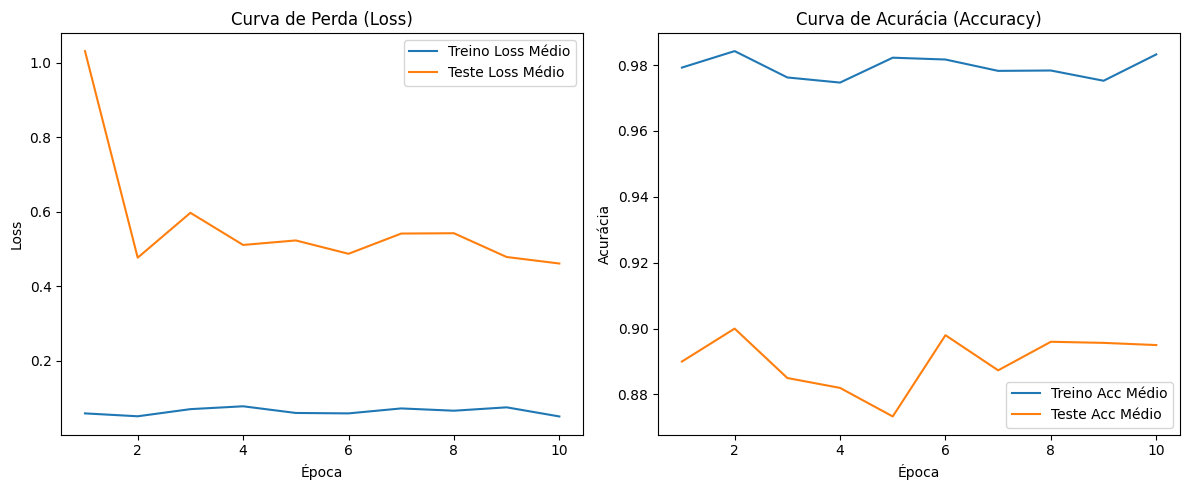

In [ ]:
#Chamada de função para visualizar como foi o treinamento
train_historic_visualization(all_train_losses_runs,all_train_accuracies_runs,all_test_losses_runs,all_test_accuracies_runs,num_epochs)

Avaliando: 100%|██████████| 10/10 [00:06<00:00,  1.51it/s]


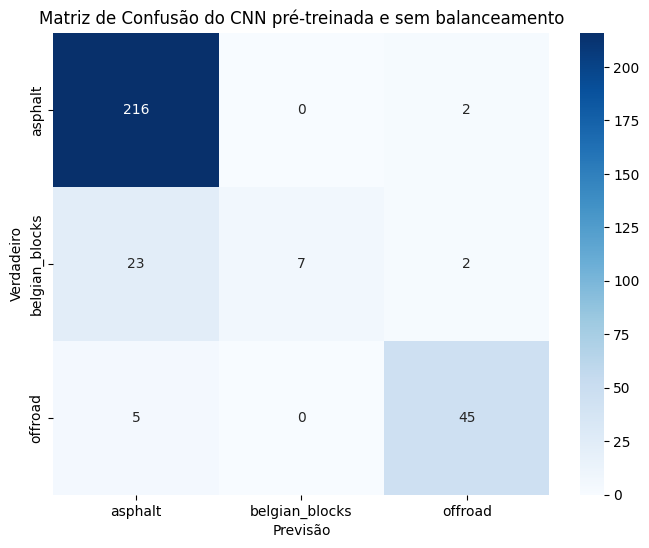


Relatório de Classificação do CNN pré-treinada e sem balanceamento:
                precision    recall  f1-score   support

       asphalt       0.89      0.99      0.94       218
belgian_blocks       1.00      0.22      0.36        32
       offroad       0.92      0.90      0.91        50

      accuracy                           0.89       300
     macro avg       0.93      0.70      0.73       300
  weighted avg       0.90      0.89      0.87       300



In [ ]:
#Função para gerar os resultados
true_labels_final, predicted_labels_final, conf_matrix_final = results(model, criterion, test_loader, device, class_names, model_description_for_title="CNN pré-treinada e sem balanceamento")

###3.1 Criando uma tabela para guadar os resultados dos testes

In [ ]:
df_results_summary_pretrained_unbalanced = gerar_e_mostrar_tabela_de_resumo(
    true_labels=true_labels_final,
    predicted_labels=predicted_labels_final,
    class_names=class_names,
    num_epochs=num_epochs,
    batch_size=batch_size,
    optimizer_obj=optimizer,
    criterion_obj=criterion,
    train_losses_history=final_run_train_losses,
    train_accuracies_history=final_run_train_accuracies,
    test_losses_history=final_run_test_losses,
    test_accuracies_history=final_run_test_accuracies,
    conf_matrix=conf_matrix_final,
    model_description="CNN pré-treinada e sem balanceamento"
)

Dicionário de resultados e parâmetros para CNN pré-treinada e sem balanceamento criado com sucesso!
Visualização tabular dos resultados e parâmetros do treinamento (CNN pré-treinada e sem balanceamento):


,Learning Rate,Epochs,Batch Size,Loss Function,Confusion Matrix,Accuracy,Macro Avg Precision,Macro Avg Recall,Macro Avg F1-Score,Weighted Avg Precision,Weighted Avg F1-Score,Weighted Avg Recall
0,0.001,10,32,CrossEntropyLoss,"[[216, 0, 2], [23, 7, 2], [5, 0, 45]]",0.89,0.93,0.70,0.73,0.90,0.87,0.89


In [ ]:
# A visualização tabular dos resultados é feita diretamente pela função generate_and_display_summary_table.

##Teste com uma CNN do zero e sem balanceamento

---



### 1. Definir a Arquitetura da CNN do Zero

Vamos criar uma arquitetura de CNN simples para classificação de imagens. Esta rede incluirá camadas convolucionais, de pooling e totalmente conectadas.

In [ ]:
# Definição da arquitetura da CNN do zero
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # 3 canais de entrada (RGB), 32 filtros, kernel 3x3
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2) # Camada de pooling 2x2

        # Para calcular a dimensão da entrada para a camada linear, precisamos simular
        # o forward pass com uma imagem de exemplo após as camadas convolucionais.
        # Considerando `transforms.Resize((384, 384))`:
        # Após 3 pools de 2x2, a dimensão espacial será 384 / (2*2*2) = 384 / 8 = 48.
        # Então, a entrada para a camada linear será 128 * 48 * 48.
        self.fc1 = nn.Linear(128 * 48 * 48, 512) # Camada totalmente conectada
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Flattening
        x = x.view(-1, 128 * 48 * 48) # Ajusta conforme as dimensões calculadas
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("Definição da classe SimpleCNN concluída.")

Definição da classe SimpleCNN concluída.


### 2. Configurar o Modelo, Otimizador e Hiperparâmetros

Vamos instanciar a nossa `SimpleCNN` e definir o otimizador e a função de perda.

In [ ]:
# Resetar o modelo para a nova arquitetura
model_scratch = SimpleCNN(num_classes=len(train_dataset.classes))
model_scratch = model_scratch.to(device)

# Redefinir otimizador e critério para o novo modelo
criterion_scratch = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)

# Hiperparâmetros de treinamento (reutilizar num_epochs)
# num_epochs = 10 # Já definido anteriormente

print(f"Modelo SimpleCNN instanciado e movido para {device}.")

Modelo SimpleCNN instanciado e movido para cuda.


### 3. Loop Principal de Treinamento e Avaliação (CNN do Zero)

Agora vamos treinar e avaliar a nossa `SimpleCNN`.

In [ ]:
#Chamada de função para execução do loop de treinamento
(all_train_losses_scratch_runs,all_train_accuracies_scratch_runs,
all_test_losses_scratch_runs,
all_test_accuracies_scratch_runs,final_run_train_losses_scratch,
final_run_train_accuracies_scratch,final_run_test_losses_scratch,final_run_test_accuracies_scratch) = principal_loop_trainning(
    num_epochs, model_scratch, criterion_scratch, optimizer_scratch, train_loader, "SimpleCNN do Zero e sem balanceamento"
)

Treino (SimpleCNN do Zero e sem balanceamento): 1/10


Epoch 1/10 (SimpleCNN do Zero e sem balanceamento)


Treinando: 100%|██████████| 29/29 [00:24<00:00,  1.18it/s]


  Treino (SimpleCNN do Zero e sem balanceamento) -> Loss: 23.4343, Acc: 0.7600


Avaliando: 100%|██████████| 10/10 [00:06<00:00,  1.44it/s]


  Teste  (SimpleCNN do Zero e sem balanceamento) -> Loss: 6.9811, Acc: 0.7167

Epoch 2/10 (SimpleCNN do Zero e sem balanceamento)


...

  Teste  (SimpleCNN do Zero e sem balanceamento) -> Loss: 0.8423, Acc: 0.8333

Epoch 10/10 (SimpleCNN do Zero e sem balanceamento)


Treinando: 100%|██████████| 29/29 [00:24<00:00,  1.16it/s]


  Treino (SimpleCNN do Zero e sem balanceamento) -> Loss: 0.0286, Acc: 0.9911


Avaliando: 100%|██████████| 10/10 [00:07<00:00,  1.39it/s]

  Teste  (SimpleCNN do Zero e sem balanceamento) -> Loss: 0.8157, Acc: 0.8633

Treinamento da SimpleCNN do Zero e sem balanceamento concluído!


### 4. Visualização do Histórico de Treinamento (CNN do Zero)

Vamos plotar as curvas de perda e acurácia para a CNN treinada do zero.

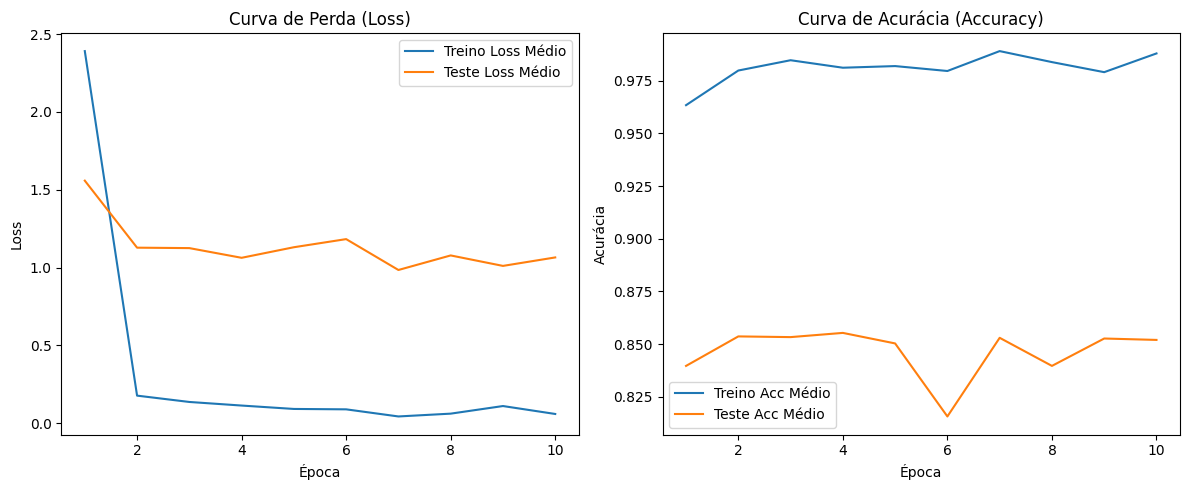

In [ ]:
#Chamada de função para visualizar como foi o treinamento
train_historic_visualization(all_train_losses_scratch_runs,all_train_accuracies_scratch_runs,all_test_losses_scratch_runs,all_test_accuracies_scratch_runs,num_epochs)

### 5. Matriz de Confusão e Relatório de Classificação (CNN do Zero)

Vamos analisar o desempenho final da CNN treinada do zero no conjunto de teste.

Avaliando: 100%|██████████| 10/10 [00:06<00:00,  1.45it/s]


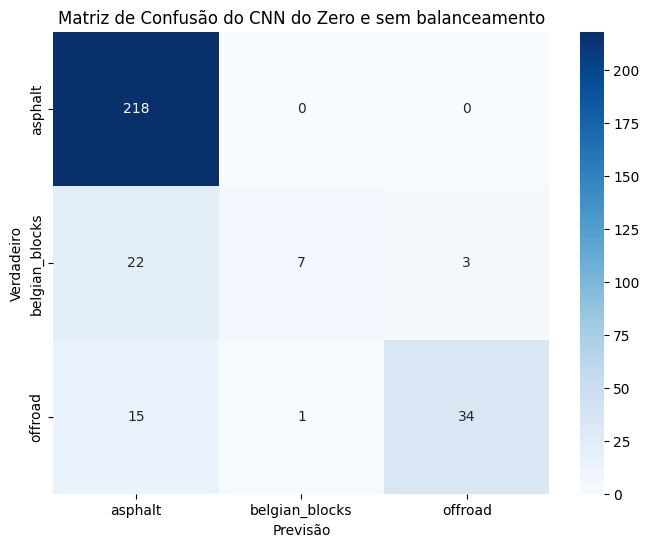


Relatório de Classificação do CNN do Zero e sem balanceamento:
                precision    recall  f1-score   support

       asphalt       0.85      1.00      0.92       218
belgian_blocks       0.88      0.22      0.35        32
       offroad       0.92      0.68      0.78        50

      accuracy                           0.86       300
     macro avg       0.88      0.63      0.68       300
  weighted avg       0.87      0.86      0.84       300



In [ ]:
true_labels_final_scratch, predicted_labels_final_scratch, conf_matrix_scratch = results(model_scratch, criterion_scratch, test_loader, device, class_names, model_description_for_title="CNN do Zero e sem balanceamento")

###6. Criando uma tabela para guadar os resultados dos testes


In [ ]:

df_results_summary_scratch_unbalanced = gerar_e_mostrar_tabela_de_resumo(
    true_labels=true_labels_final_scratch,
    predicted_labels=predicted_labels_final_scratch,
    class_names=class_names,
    num_epochs=num_epochs,
    batch_size=batch_size,
    optimizer_obj=optimizer_scratch,
    criterion_obj=criterion_scratch,
    train_losses_history=final_run_train_losses_scratch,
    train_accuracies_history=final_run_train_accuracies_scratch,
    test_losses_history=final_run_test_losses_scratch,
    test_accuracies_history=final_run_test_accuracies_scratch,
    conf_matrix=conf_matrix_scratch,
    model_description="CNN do Zero e sem balanceamento"
)

Dicionário de resultados e parâmetros para CNN do Zero e sem balanceamento criado com sucesso!
Visualização tabular dos resultados e parâmetros do treinamento (CNN do Zero e sem balanceamento):


,Learning Rate,Epochs,Batch Size,Loss Function,Confusion Matrix,Accuracy,Macro Avg Precision,Macro Avg Recall,Macro Avg F1-Score,Weighted Avg Precision,Weighted Avg F1-Score,Weighted Avg Recall
0,0.001,10,32,CrossEntropyLoss,"[[218, 0, 0], [22, 7, 3], [15, 1, 34]]",0.86,0.88,0.63,0.68,0.87,0.84,0.86


##Treinando com uma rede pré treinada e os dados balanceados

---

###1.Balanceamento por oversampling

#### 1.1. Cálculo de Pesos para Oversampling e Configuração do DataLoader

In [ ]:
# Recalcular as contagens de classes no dataset de treino
# 'class_counts' já foi definido e contém a contagem de imagens por classe.
class_counts_list,total_samples = count_class_occurrences(train_dataset)

# Calcular os pesos inversamente proporcionais à frequência das classes
# Isso dará mais peso às classes minoritárias
class_weights = [total_samples / count for count in class_counts_list]

# Criar uma lista de pesos para cada amostra no dataset
# Cada amostra terá o peso correspondente à sua classe
sample_weights = [class_weights[label] for label in train_dataset.targets]

# Criar o sampler para o DataLoader de treino
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=total_samples, # Garante que todas as amostras (incluindo as "repetidas") serão consideradas
    replacement=True # Permite que amostras sejam selecionadas mais de uma vez
)

# Criar o novo DataLoader de treino com o sampler
# O batch_size permanece o mesmo, mas o sampler vai "ditar" como as amostras são escolhidas
train_loader_balanced = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)

print("DataLoader de treino balanceado criado com sucesso usando WeightedRandomSampler.")
print(f"Pesos das classes: {class_weights}")

# É importante notar que o test_loader não precisa ser balanceado, pois queremos avaliar o modelo no dataset real, dessa forma evitando data l.

DataLoader de treino balanceado criado com sucesso usando WeightedRandomSampler.
Pesos das classes: [1.3740458015267176, 9.574468085106384, 5.960264900662252]


#### 2.1. Configuração do Modelo e Hiperparâmetros (ResNet18 com Oversampling)

In [ ]:
  # Reiniciar o modelo ResNet18 pré-treinado
model_balanced = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Substituir a camada final (fully connected)(para apenas 3 saídas)
num_ftrs_balanced = model_balanced.fc.in_features
model_balanced.fc = nn.Linear(num_ftrs_balanced, len(train_dataset.classes))

# Mover o modelo para o dispositivo selecionado
model_balanced = model_balanced.to(device)

# Definir a função de perda e o otimizador
criterion_balanced = nn.CrossEntropyLoss()
optimizer_balanced = optim.Adam(model_balanced.parameters(), lr=0.001)

# Hiperparâmetros de treinamento (reutilizar num_epochs)
# num_epochs = 10 # Já definido anteriormente

print("Modelo ResNet18 para treinamento com balanceamento configurado.")

Modelo ResNet18 para treinamento com balanceamento configurado.


#### 3.1. Loop Principal de Treinamento e Avaliação (ResNet18 com Oversampling)

In [ ]:
#Chamada de função para execução do loop de treinamento
(all_train_losses_balanced_runs,all_train_accuracies_balanced_runs,
all_test_losses_balanced_runs,all_test_accuracies_balanced_runs,
final_run_train_losses_balanced, final_run_train_accuracies_balanced,
final_run_test_losses_balanced, final_run_test_accuracies_balanced) = principal_loop_cnn_pre_trained(num_epochs)

Treino: 1/10

Epoch 1/10


Treinando: 100%|██████████| 29/29 [00:29<00:00,  1.01s/it]


  Treino -> Loss: 0.2983, Acc: 0.9000


Avaliando: 100%|██████████| 10/10 [00:06<00:00,  1.54it/s]


  Teste  -> Loss: 1.2140, Acc: 0.7333

Epoch 2/10


...

  Teste  -> Loss: 0.5644, Acc: 0.8867

Epoch 10/10


Treinando: 100%|██████████| 29/29 [00:25<00:00,  1.13it/s]


  Treino -> Loss: 0.0520, Acc: 0.9844


Avaliando: 100%|██████████| 10/10 [00:06<00:00,  1.50it/s]

  Teste  -> Loss: 0.6810, Acc: 0.8867

Treinamento concluído!


#### 4.1. Visualização do Histórico de Treinamento (ResNet18 com Oversampling)

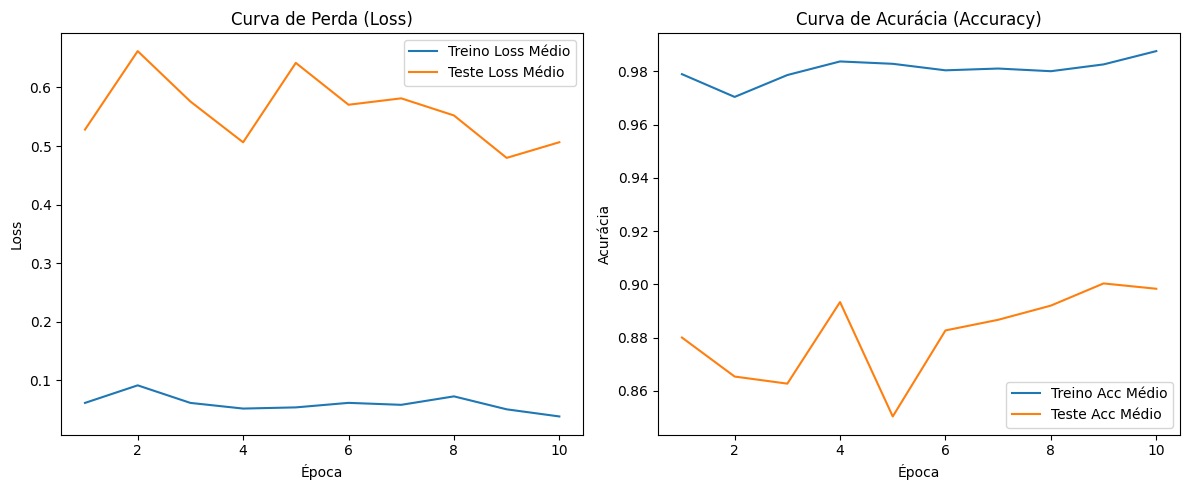

In [ ]:
#Chamada de função para visualizar como foi o treinamento
train_historic_visualization(all_train_losses_balanced_runs,all_train_accuracies_balanced_runs,all_test_losses_balanced_runs,all_test_accuracies_balanced_runs,num_epochs)

#### 5.1. Matriz de Confusão e Relatório de Classificação (ResNet18 com Oversampling)

Avaliando: 100%|██████████| 10/10 [00:07<00:00,  1.36it/s]


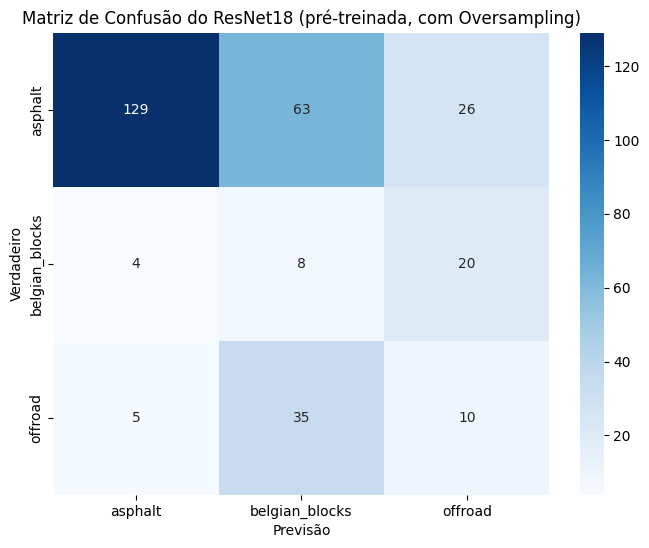


Relatório de Classificação do ResNet18 (pré-treinada, com Oversampling):
                precision    recall  f1-score   support

       asphalt       0.93      0.59      0.72       218
belgian_blocks       0.08      0.25      0.12        32
       offroad       0.18      0.20      0.19        50

      accuracy                           0.49       300
     macro avg       0.40      0.35      0.34       300
  weighted avg       0.72      0.49      0.57       300



In [ ]:
true_labels_final_balanced, predicted_labels_final_balanced, conf_matrix_balanced = results(model_balanced, criterion_balanced, test_loader, device, class_names, model_description_for_title="ResNet18 (pré-treinada, com Oversampling)")

####6.1. Criando uma tabela para guadar os resultados dos testes


In [ ]:
df_results_summary_pretrained_oversampling = gerar_e_mostrar_tabela_de_resumo(
    true_labels=true_labels_final_balanced,
    predicted_labels=predicted_labels_final_balanced,
    class_names=class_names,
    num_epochs=num_epochs,
    batch_size=batch_size,
    optimizer_obj=optimizer_balanced,
    criterion_obj=criterion_balanced,
    train_losses_history=final_run_train_losses_balanced,
    train_accuracies_history=final_run_train_accuracies_balanced,
    test_losses_history=final_run_test_losses_balanced,
    test_accuracies_history=final_run_test_accuracies_balanced,
    conf_matrix=conf_matrix_balanced,
    model_description="ResNet18 (pré-treinada, com Oversampling)"
)

Dicionário de resultados e parâmetros para ResNet18 (pré-treinada, com Oversampling) criado com sucesso!
Visualização tabular dos resultados e parâmetros do treinamento (ResNet18 (pré-treinada, com Oversampling)):


,Learning Rate,Epochs,Batch Size,Loss Function,Confusion Matrix,Accuracy,Macro Avg Precision,Macro Avg Recall,Macro Avg F1-Score,Weighted Avg Precision,Weighted Avg F1-Score,Weighted Avg Recall
0,0.001,10,32,CrossEntropyLoss,"[[129, 63, 26], [4, 8, 20], [5, 35, 10]]",0.49,0.40,0.35,0.34,0.72,0.57,0.49


###2. Balanceamento por pesos

#### 1.2 Cálculo dos Pesos das Classes para a Função de Perda

In [ ]:
# Recalcular as contagens de classes no dataset de treino
# 'class_counts' já foi definido e contém a contagem de imagens por classe.
class_counts_list,_ = count_class_occurrences(train_dataset)

# Converter para tensor PyTorch
class_counts_tensor = torch.tensor(class_counts_list, dtype=torch.float32)

# Calcular pesos inversamente proporcionais à frequência das classes
# Onde uma classe tem mais amostras, seu peso será menor.
# Onde uma classe tem menos amostras, seu peso será maior.
class_weights_loss = 1.0 / class_counts_tensor
class_weights_loss = class_weights_loss / class_weights_loss.sum()

# Mover os pesos para o dispositivo (GPU/CPU)
class_weights_loss = class_weights_loss.to(device)

print(f"Pesos das classes para a função de perda: {class_weights_loss}")
print(f"Classes: {train_dataset.classes}")

Pesos das classes para a função de perda: tensor([0.0813, 0.5662, 0.3525], device='cuda:0')
Classes: ['asphalt', 'belgian_blocks', 'offroad']


#### 2.2 Configuração do Modelo e Hiperparâmetros (ResNet18 com Pesos de Classe)

In [ ]:
# Reiniciar o modelo ResNet18 pré-treinado
model_weighted = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Substituir a camada final (fully connected)
num_ftrs_weighted = model_weighted.fc.in_features
model_weighted.fc = nn.Linear(num_ftrs_weighted, len(train_dataset.classes))

# Mover o modelo para o dispositivo selecionado
model_weighted = model_weighted.to(device)

# Definir a função de perda com os pesos das classes
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights_loss)
optimizer_weighted = optim.Adam(model_weighted.parameters(), lr=0.001)

# Hiperparâmetros de treinamento (reutilizar num_epochs)
# num_epochs = 10 # Já definido anteriormente

print("Modelo ResNet18 para treinamento com pesos de classe configurado.")

Modelo ResNet18 para treinamento com pesos de classe configurado.


####3.2 Loop Principal de Treinamento e Avaliação (ResNet18 com Pesos de Classe)

In [ ]:
#Chamada de função para execução do loop de treinamento
(all_train_losses_weighted_runs,all_train_accuracies_weighted_runs,
all_test_losses_weighted_runs,all_test_accuracies_weighted_runs,
final_run_train_losses_weighted, final_run_train_accuracies_weighted,
final_run_test_losses_weighted, final_run_test_accuracies_weighted) = principal_loop_cnn_pre_trained(num_epochs)

Treino: 1/10

Epoch 1/10


Treinando: 100%|██████████| 29/29 [00:25<00:00,  1.13it/s]


  Treino -> Loss: 0.0279, Acc: 0.9944


Avaliando: 100%|██████████| 10/10 [00:07<00:00,  1.37it/s]


  Teste  -> Loss: 0.5914, Acc: 0.8800

Epoch 2/10


...

  Teste  -> Loss: 0.8486, Acc: 0.8767

Epoch 10/10


Treinando: 100%|██████████| 29/29 [00:25<00:00,  1.14it/s]


  Treino -> Loss: 0.0078, Acc: 0.9967


Avaliando: 100%|██████████| 10/10 [00:06<00:00,  1.51it/s]

  Teste  -> Loss: 0.7446, Acc: 0.8867

Treinamento concluído!


#### 4.2 Visualização do Histórico de Treinamento (ResNet18 com Pesos de Classe)

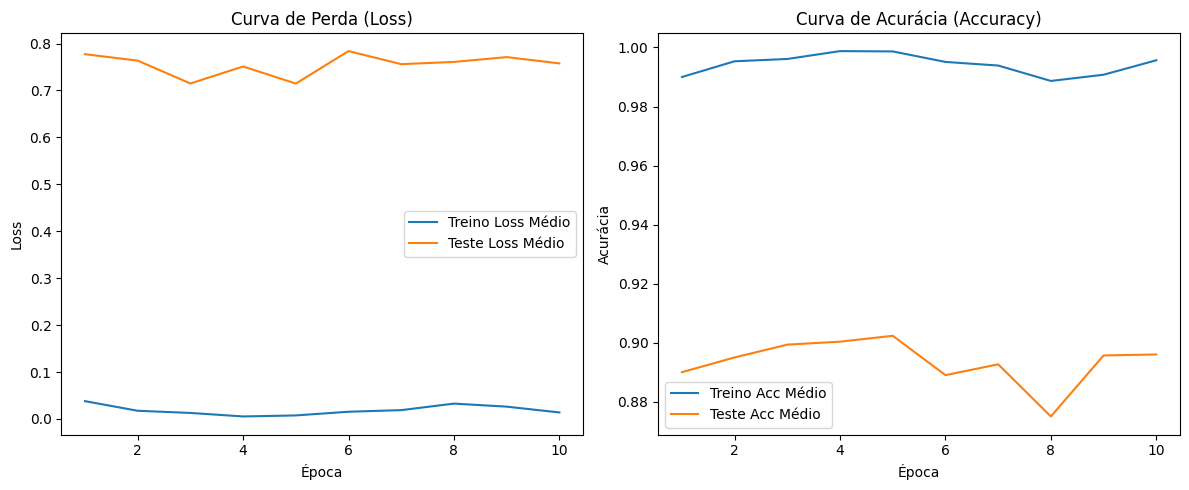

In [ ]:
#Chamada de função para visualizar como foi o treinamento
train_historic_visualization(all_train_losses_weighted_runs,all_train_accuracies_weighted_runs,all_test_losses_weighted_runs,all_test_accuracies_weighted_runs,num_epochs)

#### 5.2 Matriz de Confusão e Relatório de Classificação (ResNet18 com Pesos de Classe)

Avaliando: 100%|██████████| 10/10 [00:07<00:00,  1.38it/s]


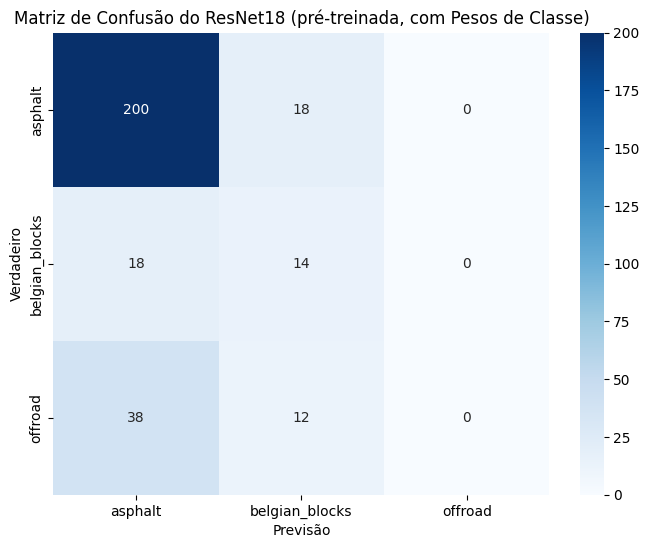


Relatório de Classificação do ResNet18 (pré-treinada, com Pesos de Classe):
                precision    recall  f1-score   support

       asphalt       0.78      0.92      0.84       218
belgian_blocks       0.32      0.44      0.37        32
       offroad       0.00      0.00      0.00        50

      accuracy                           0.71       300
     macro avg       0.37      0.45      0.40       300
  weighted avg       0.60      0.71      0.65       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
true_labels_final_weighted, predicted_labels_final_weighted, conf_matrix_weighted = results(model_weighted, criterion_weighted, test_loader, device, class_names, model_description_for_title="ResNet18 (pré-treinada, com Pesos de Classe)")

####6.2. Criando uma tabela para guadar os resultados dos testes


In [ ]:
df_results_summary_pretrained_weighted = gerar_e_mostrar_tabela_de_resumo(
    true_labels=true_labels_final_weighted,
    predicted_labels=predicted_labels_final_weighted,
    class_names=class_names,
    num_epochs=num_epochs,
    batch_size=batch_size,
    optimizer_obj=optimizer_weighted,
    criterion_obj=criterion_weighted,
    train_losses_history=final_run_train_losses_weighted,
    train_accuracies_history=final_run_train_accuracies_weighted,
    test_losses_history=final_run_test_losses_weighted,
    test_accuracies_history=final_run_test_accuracies_weighted,
    conf_matrix=conf_matrix_weighted,
    model_description="ResNet18 (pré-treinada, com Pesos de Classe)",
    class_weights=class_weights_loss
)

Dicionário de resultados e parâmetros para ResNet18 (pré-treinada, com Pesos de Classe) criado com sucesso!
Visualização tabular dos resultados e parâmetros do treinamento (ResNet18 (pré-treinada, com Pesos de Classe)):


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Learning Rate,Epochs,Batch Size,Loss Function,Confusion Matrix,Accuracy,Macro Avg Precision,Macro Avg Recall,Macro Avg F1-Score,Weighted Avg Precision,Weighted Avg F1-Score,Weighted Avg Recall,Class Weights
0,0.001,10,32,CrossEntropyLoss,"[[200, 18, 0], [18, 14, 0], [38, 12, 0]]",0.71,0.37,0.45,0.40,0.60,0.65,0.71,"[0.0812622681260109, 0.5662423968315125, 0.3524952828884125]"


##Treinamento Balanceado com a rede do zero

---

###1. Balanceamento por oversampling (CNN do Zero)

#### 1.1. Cálculo de Pesos para Oversampling e Configuração do DataLoader (CNN do Zero)

In [ ]:
# Recalcular as contagens de classes no dataset de treino
# 'class_counts' já foi definido e contém a contagem de imagens por classe.
class_counts_list_cnn_balanced,total_samples_cnn_balanced = count_class_occurrences(train_dataset)

# Calcular os pesos inversamente proporcionais à frequência das classes
# Isso dará mais peso às classes minoritárias
class_weights_cnn_balanced = [total_samples_cnn_balanced / count for count in class_counts_list_cnn_balanced]

# Criar uma lista de pesos para cada amostra no dataset
# Cada amostra terá o peso correspondente à sua classe
sample_weights_cnn_balanced = [class_weights_cnn_balanced[label] for label in train_dataset.targets]

# Criar o sampler para o DataLoader de treino
sampler_cnn_balanced = WeightedRandomSampler(
    weights=sample_weights_cnn_balanced,
    num_samples=total_samples_cnn_balanced,
    replacement=True
)

# Criar o novo DataLoader de treino com o sampler
train_loader_cnn_balanced = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler_cnn_balanced)

print("DataLoader de treino balanceado para CNN do Zero criado com sucesso usando WeightedRandomSampler.")
print(f"Pesos das classes: {class_weights_cnn_balanced}")

DataLoader de treino balanceado para CNN do Zero criado com sucesso usando WeightedRandomSampler.
Pesos das classes: [1.3740458015267176, 9.574468085106384, 5.960264900662252]


#### 2.1. Configuração do Modelo e Hiperparâmetros (SimpleCNN com Oversampling)

In [ ]:
# Reiniciar o modelo para a nova arquitetura
model_cnn_balanced = SimpleCNN(num_classes=len(train_dataset.classes))
model_cnn_balanced = model_cnn_balanced.to(device)

# Redefinir otimizador e critério para o novo modelo
criterion_cnn_balanced = nn.CrossEntropyLoss()
optimizer_cnn_balanced = optim.Adam(model_cnn_balanced.parameters(), lr=0.001)

print(f"Modelo SimpleCNN para oversampling instanciado e movido para {device}.")

Modelo SimpleCNN para oversampling instanciado e movido para cuda.


#### 3.1. Loop Principal de Treinamento e Avaliação (SimpleCNN com Oversampling)

In [ ]:
#Chamada de função para execução do loop de treinamento
(all_train_losses_cnn_balanced_runs,all_train_accuracies_cnn_balanced_runs,
all_test_losses_cnn_balanced_runs,all_test_accuracies_cnn_balanced_runs,
final_run_train_losses_cnn_balanced, final_run_train_accuracies_cnn_balanced,
final_run_test_losses_cnn_balanced, final_run_test_accuracies_cnn_balanced) = principal_loop_trainning(
    num_epochs,
    model_cnn_balanced,
    criterion_cnn_balanced,
    optimizer_cnn_balanced,
    train_loader_cnn_balanced,
    "SimpleCNN (do zero, com Oversampling)"
)

Treino (SimpleCNN (do zero, com Oversampling)): 1/10


Epoch 1/10 (SimpleCNN (do zero, com Oversampling))


Treinando: 100%|██████████| 29/29 [00:26<00:00,  1.11it/s]


  Treino (SimpleCNN (do zero, com Oversampling)) -> Loss: 42.7176, Acc: 0.6544


Avaliando: 100%|██████████| 10/10 [00:07<00:00,  1.37it/s]


  Teste  (SimpleCNN (do zero, com Oversampling)) -> Loss: 11.3078, Acc: 0.7567

Epoch 2/10 (SimpleCNN (do zero, com Oversampling))


...

  Teste  (SimpleCNN (do zero, com Oversampling)) -> Loss: 1.2440, Acc: 0.8567

Epoch 10/10 (SimpleCNN (do zero, com Oversampling))


Treinando: 100%|██████████| 29/29 [00:25<00:00,  1.12it/s]


  Treino (SimpleCNN (do zero, com Oversampling)) -> Loss: 0.0001, Acc: 1.0000


Avaliando: 100%|██████████| 10/10 [00:07<00:00,  1.39it/s]

  Teste  (SimpleCNN (do zero, com Oversampling)) -> Loss: 1.1997, Acc: 0.8567

Treinamento da SimpleCNN (do zero, com Oversampling) concluído!


#### 4.1. Visualização do Histórico de Treinamento (SimpleCNN com Oversampling)

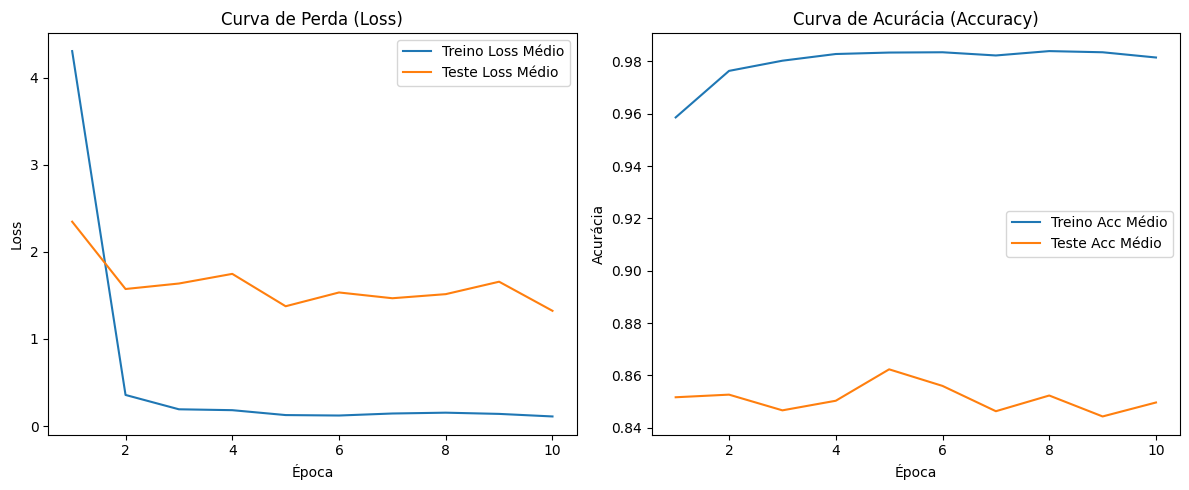

In [ ]:
#Chamada de função para visualizar como foi o treinamento
train_historic_visualization(all_train_losses_cnn_balanced_runs,all_train_accuracies_cnn_balanced_runs,all_test_losses_cnn_balanced_runs,all_test_accuracies_cnn_balanced_runs,num_epochs)

#### 5.1. Matriz de Confusão e Relatório de Classificação (SimpleCNN com Oversampling)

Avaliando: 100%|██████████| 10/10 [00:06<00:00,  1.49it/s]


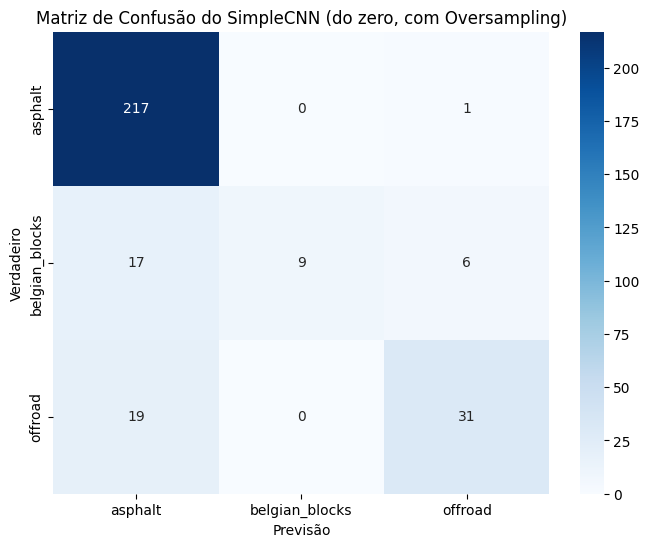


Relatório de Classificação do SimpleCNN (do zero, com Oversampling):
                precision    recall  f1-score   support

       asphalt       0.86      1.00      0.92       218
belgian_blocks       1.00      0.28      0.44        32
       offroad       0.82      0.62      0.70        50

      accuracy                           0.86       300
     macro avg       0.89      0.63      0.69       300
  weighted avg       0.87      0.86      0.83       300



In [ ]:
true_labels_final_cnn_balanced, predicted_labels_final_cnn_balanced, conf_matrix_cnn_balanced = results(model_cnn_balanced, criterion_cnn_balanced, test_loader, device, class_names, model_description_for_title="SimpleCNN (do zero, com Oversampling)")

####6.1. Criando uma tabela para guadar os resultados dos testes


In [ ]:
df_results_summary_scratch_oversampling = gerar_e_mostrar_tabela_de_resumo(
    true_labels=true_labels_final_cnn_balanced,
    predicted_labels=predicted_labels_final_cnn_balanced,
    class_names=class_names,
    num_epochs=num_epochs,
    batch_size=batch_size,
    optimizer_obj=optimizer_cnn_balanced,
    criterion_obj=criterion_cnn_balanced,
    train_losses_history=final_run_train_losses_cnn_balanced,
    train_accuracies_history=final_run_train_accuracies_cnn_balanced,
    test_losses_history=final_run_test_losses_cnn_balanced,
    test_accuracies_history=final_run_test_accuracies_cnn_balanced,
    conf_matrix=conf_matrix_cnn_balanced,
    model_description="SimpleCNN (do zero, com Oversampling)"
)

Dicionário de resultados e parâmetros para SimpleCNN (do zero, com Oversampling) criado com sucesso!
Visualização tabular dos resultados e parâmetros do treinamento (SimpleCNN (do zero, com Oversampling)):


,Learning Rate,Epochs,Batch Size,Loss Function,Confusion Matrix,Accuracy,Macro Avg Precision,Macro Avg Recall,Macro Avg F1-Score,Weighted Avg Precision,Weighted Avg F1-Score,Weighted Avg Recall
0,0.001,10,32,CrossEntropyLoss,"[[217, 0, 1], [17, 9, 6], [19, 0, 31]]",0.86,0.89,0.63,0.69,0.87,0.83,0.86


###2. Balanceamento por pesos (CNN do Zero)

#### 1.2 Cálculo dos Pesos das Classes para a Função de Perda (CNN do Zero)

In [ ]:
# Recalcular as contagens de classes no dataset de treino
class_counts_list_cnn_weighted,_ = count_class_occurrences(train_dataset)

# Converter para tensor PyTorch
class_counts_tensor_cnn_weighted = torch.tensor(class_counts_list_cnn_weighted, dtype=torch.float32)

# Calcular pesos inversamente proporcionais à frequência das classes
class_weights_loss_cnn_weighted = 1.0 / class_counts_tensor_cnn_weighted
class_weights_loss_cnn_weighted = class_weights_loss_cnn_weighted / class_weights_loss_cnn_weighted.sum()

# Mover os pesos para o dispositivo (GPU/CPU)
class_weights_loss_cnn_weighted = class_weights_loss_cnn_weighted.to(device)

print(f"Pesos das classes para a função de perda (SimpleCNN): {class_weights_loss_cnn_weighted}")
print(f"Classes: {train_dataset.classes}")

Pesos das classes para a função de perda (SimpleCNN): tensor([0.0813, 0.5662, 0.3525], device='cuda:0')
Classes: ['asphalt', 'belgian_blocks', 'offroad']


#### 2.2 Configuração do Modelo e Hiperparâmetros (SimpleCNN com Pesos de Classe)

In [ ]:
# Reiniciar o modelo SimpleCNN
model_cnn_weighted = SimpleCNN(num_classes=len(train_dataset.classes))
model_cnn_weighted = model_cnn_weighted.to(device)

# Definir a função de perda com os pesos das classes
criterion_cnn_weighted = nn.CrossEntropyLoss(weight=class_weights_loss_cnn_weighted)
optimizer_cnn_weighted = optim.Adam(model_cnn_weighted.parameters(), lr=0.001)

print("Modelo SimpleCNN para treinamento com pesos de classe configurado.")

Modelo SimpleCNN para treinamento com pesos de classe configurado.


####3.2 Loop Principal de Treinamento e Avaliação (SimpleCNN com Pesos de Classe)

In [ ]:
#Chamada de função para execução do loop de treinamento
(all_train_losses_cnn_weighted_runs,all_train_accuracies_cnn_weighted_runs,
all_test_losses_cnn_weighted_runs,all_test_accuracies_cnn_weighted_runs,
final_run_train_losses_cnn_weighted, final_run_train_accuracies_cnn_weighted,
final_run_test_losses_cnn_weighted, final_run_test_accuracies_cnn_weighted)= principal_loop_trainning(
    num_epochs,
    model_cnn_weighted,
    criterion_cnn_weighted,
    optimizer_cnn_weighted,
    train_loader_cnn_balanced,
    "SimpleCNN (do zero, com Pesos de Classe)"
)

Treino (SimpleCNN (do zero, com Pesos de Classe)): 1/10


Epoch 1/10 (SimpleCNN (do zero, com Pesos de Classe))


Treinando: 100%|██████████| 29/29 [00:26<00:00,  1.11it/s]


  Treino (SimpleCNN (do zero, com Pesos de Classe)) -> Loss: 32.8405, Acc: 0.5967


Avaliando: 100%|██████████| 10/10 [00:06<00:00,  1.55it/s]


  Teste  (SimpleCNN (do zero, com Pesos de Classe)) -> Loss: 26.4781, Acc: 0.1967

Epoch 2/10 (SimpleCNN (do zero, com Pesos de Classe))


...

  Teste  (SimpleCNN (do zero, com Pesos de Classe)) -> Loss: 1.3291, Acc: 0.8533

Epoch 10/10 (SimpleCNN (do zero, com Pesos de Classe))


Treinando: 100%|██████████| 29/29 [00:25<00:00,  1.13it/s]


  Treino (SimpleCNN (do zero, com Pesos de Classe)) -> Loss: 0.0156, Acc: 0.9911


Avaliando: 100%|██████████| 10/10 [00:07<00:00,  1.40it/s]

  Teste  (SimpleCNN (do zero, com Pesos de Classe)) -> Loss: 2.0037, Acc: 0.8467

Treinamento da SimpleCNN (do zero, com Pesos de Classe) concluído!


#### 4.2 Visualização do Histórico de Treinamento (SimpleCNN com Pesos de Classe)

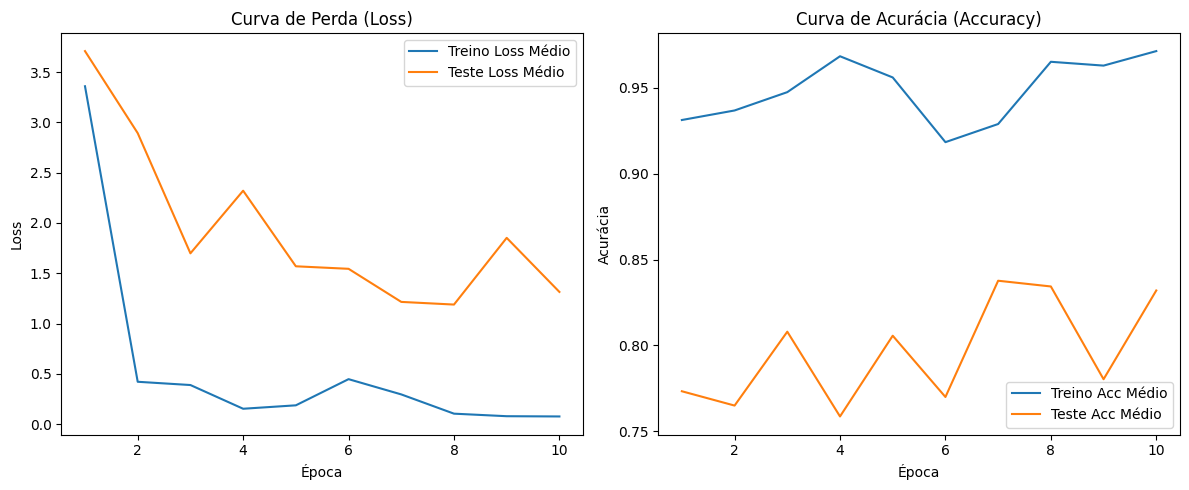

In [ ]:
#Chamada de função para visualizar como foi o treinamento
train_historic_visualization(all_train_losses_cnn_weighted_runs,all_train_accuracies_cnn_weighted_runs,all_test_losses_cnn_weighted_runs,all_test_accuracies_cnn_weighted_runs,num_epochs)

#### 5.2 Matriz de Confusão e Relatório de Classificação (SimpleCNN com Pesos de Classe)

Avaliando: 100%|██████████| 10/10 [00:06<00:00,  1.58it/s]


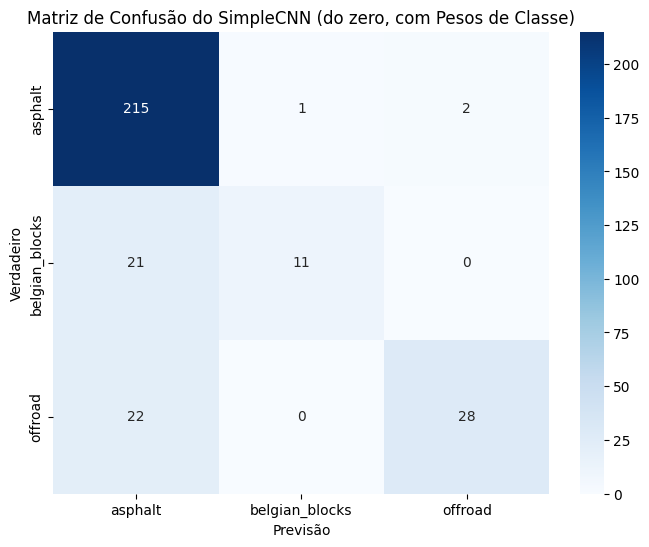


Relatório de Classificação do SimpleCNN (do zero, com Pesos de Classe):
                precision    recall  f1-score   support

       asphalt       0.83      0.99      0.90       218
belgian_blocks       0.92      0.34      0.50        32
       offroad       0.93      0.56      0.70        50

      accuracy                           0.85       300
     macro avg       0.89      0.63      0.70       300
  weighted avg       0.86      0.85      0.83       300



In [ ]:
true_labels_final_cnn_weighted, predicted_labels_final_cnn_weighted, conf_matrix_cnn_weighted = results(model_cnn_weighted, criterion_cnn_weighted, test_loader, device, class_names, model_description_for_title="SimpleCNN (do zero, com Pesos de Classe)")

####6.2. Criando uma tabela para guadar os resultados dos testes


In [ ]:
df_results_summary_scratch_weighted = gerar_e_mostrar_tabela_de_resumo(
    true_labels=true_labels_final_cnn_weighted,
    predicted_labels=predicted_labels_final_cnn_weighted,
    class_names=class_names,
    num_epochs=num_epochs,
    batch_size=batch_size,
    optimizer_obj=optimizer_cnn_weighted,
    criterion_obj=criterion_cnn_weighted,
    train_losses_history=final_run_train_losses_cnn_weighted,
    train_accuracies_history=final_run_train_accuracies_cnn_weighted,
    test_losses_history=final_run_test_losses_cnn_weighted,
    test_accuracies_history=final_run_test_accuracies_cnn_weighted,
    conf_matrix=conf_matrix_cnn_weighted,
    model_description="SimpleCNN (do zero, com Pesos de Classe)",
    class_weights=class_weights_loss_cnn_weighted
)

Dicionário de resultados e parâmetros para SimpleCNN (do zero, com Pesos de Classe) criado com sucesso!
Visualização tabular dos resultados e parâmetros do treinamento (SimpleCNN (do zero, com Pesos de Classe)):


,Learning Rate,Epochs,Batch Size,Loss Function,Confusion Matrix,Accuracy,Macro Avg Precision,Macro Avg Recall,Macro Avg F1-Score,Weighted Avg Precision,Weighted Avg F1-Score,Weighted Avg Recall,Class Weights
0,0.001,10,32,CrossEntropyLoss,"[[215, 1, 2], [21, 11, 0], [22, 0, 28]]",0.85,0.89,0.63,0.70,0.86,0.83,0.85,"[0.0812622681260109, 0.5662423968315125, 0.3524952828884125]"


##Teste com CNN pré-treinada e contraste como entrada

---

### 1. Preparação dos Dados: Custom Dataset e DataLoaders com Contraste

Primeiro, precisamos criar um `Dataset` customizado que retorne a imagem, o label e o valor de contraste para cada amostra.

In [ ]:
# Custom Dataset para incluir o contraste
class RoadDataset(torch.utils.data.Dataset):
    def __init__(self, image_dataset, metrics_df_for_contrast, transform=None):
        self.image_dataset = image_dataset
        # Garante que metrics_df_for_contrast é indexado por 'path' para busca rápida
        self.metrics_df_indexed = metrics_df_for_contrast.set_index('path')
        self.transform = transform

        self.samples = []
        for path, target in self.image_dataset.samples:
            if path in self.metrics_df_indexed.index:
                self.samples.append((path, target))
            else:
                print(f"Aviso: Imagem {path} não encontrada no metrics_df e será ignorada.")


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Obter o valor de contraste usando o caminho da imagem
        # Certifique-se de que o contraste é um tensor float32
        contrast_value = torch.tensor(self.metrics_df_indexed.loc[img_path]['contrast'], dtype=torch.float32)

        return image, contrast_value, label

print("Classe RoadDataset definida.")

# Criar datasets customizados com contraste
train_dataset_contrast = RoadDataset(train_dataset, metrics_df, transform=transform_train)
test_dataset_contrast = RoadDataset(test_dataset, metrics_df, transform=transform_test)

# Criar DataLoaders para os datasets com contraste
train_loader_contrast = DataLoader(train_dataset_contrast, batch_size=batch_size, shuffle=True)
test_loader_contrast = DataLoader(test_dataset_contrast, batch_size=batch_size, shuffle=False)

print(f"Número de imagens de treino com contraste: {len(train_dataset_contrast)}")
print(f"Número de imagens de teste com contraste: {len(test_dataset_contrast)}")


Classe RoadDataset definida.
Número de imagens de treino com contraste: 900
Número de imagens de teste com contraste: 300


### 2. Nova Arquitetura do Modelo (ResNet com Contraste)

Vamos definir um novo modelo que integra um ResNet18 pré-treinado com a feature de contraste. As features da ResNet e o contraste serão processados separadamente e depois concatenados antes da camada de classificação final.

In [ ]:
class ResNetContrast(nn.Module):
    def __init__(self, num_classes=3, dropout_rate=0.5):
        super(ResNetContrast, self).__init__()
        # Carregar o ResNet18 pré-treinado
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Congelar todos os parâmetros do ResNet para evitar que sejam atualizados
        for param in self.resnet.parameters():
            param.requires_grad = False

        # Remover a camada final de classificação original do ResNet
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity() # Substitui a camada FC por uma camada de identidade para obter as features antes da classificação, é aqui que entra o contraste

        # Camada densa para processar as features do ResNet
        self.resnet_features_processor = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )

        # Camada densa para processar a feature de contraste
        self.contrast_processor = nn.Sequential(
            nn.Linear(1, 64), # Entrada de 1 para o contraste, saída de 64
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )

        # Camada de classificação final após concatenação
        # 512 (do resnet_features_processor) + 64 (do contrast_processor)
        self.classifier = nn.Sequential(
            nn.Linear(512 + 64, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, image, contrast):
        # Passar a imagem pelo ResNet
        resnet_output = self.resnet(image)
        resnet_processed = self.resnet_features_processor(resnet_output)

        # Processar o valor de contraste
        # contrast.unsqueeze(1) adiciona uma dimensão para que seja compatível com a camada Linear
        contrast_processed = self.contrast_processor(contrast.unsqueeze(1))

        # Concatenar as features processadas do ResNet e do contraste
        combined_features = torch.cat((resnet_processed, contrast_processed), dim=1)

        # Classificação final
        output = self.classifier(combined_features)
        return output

print("Classe ResNetContrast definida.")


Classe ResNetContrast definida.


### 3. Funções de Treinamento e Avaliação Adaptadas para Contraste

Vamos criar novas versões das funções de treinamento e avaliação que aceitam o valor de contraste como um input adicional.

In [ ]:
# Adaptada para receber o valor de contraste
def train_model_with_contrast(model, criterion, optimizer, train_loader, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for inputs, contrasts, labels in tqdm(train_loader, desc="Treinando (com contraste)"):
        inputs, contrasts, labels = inputs.to(device), contrasts.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs, contrasts) # Passa inputs e contrasts
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_predictions / total_predictions
    return epoch_loss, epoch_acc

# Adaptada para receber o valor de contraste
def evaluate_model_with_contrast(model, criterion, test_loader, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, contrasts, labels in tqdm(test_loader, desc="Avaliando (com contraste)"):
            inputs, contrasts, labels = inputs.to(device), contrasts.to(device), labels.to(device)

            outputs = model(inputs, contrasts) # Passa inputs e contrasts
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    epoch_loss = running_loss / len(test_loader.dataset)
    epoch_acc = correct_predictions / total_predictions
    return epoch_loss, epoch_acc, all_labels, all_predictions

print("Funções de treinamento e avaliação com contraste definidas.")


Funções de treinamento e avaliação com contraste definidas.


### 4. Loop Principal de Treinamento e Avaliação (ResNet com Contraste)

Agora, vamos rodar o treinamento usando o novo modelo e as funções adaptadas.

In [ ]:
def principal_loop_with_contrast(num_epochs, model, criterion, optimizer, train_loader, test_loader, model_name="Modelo", device=None):
    all_train_losses_runs = []
    all_train_accuracies_runs = []
    all_test_losses_runs = []
    all_test_accuracies_runs = []

    final_run_train_losses = []
    final_run_train_accuracies = []
    final_run_test_losses = []
    final_run_test_accuracies = []

    for i in range(10): # Rodando 10 vezes para uma avaliação mais robusta
        print(f"Treino ({model_name}): {i+1}/10\n")

        current_run_train_losses = []
        current_run_train_accuracies = []
        current_run_test_losses = []
        current_run_test_accuracies = []

        # Para cada 'run', re-inicializamos o modelo para garantir que o treinamento comece do zero
        # e para simular a aleatoriedade de pesos e inicialização que pode ocorrer.
        # Re-instancia o modelo para cada run
        model_current_run = ResNetContrast(num_classes=len(class_names)).to(device)
        optimizer_current_run = optim.Adam(model_current_run.parameters(), lr=0.001)

        for epoch in range(num_epochs):
            print(f"\nEpoch {epoch+1}/{num_epochs} ({model_name})")

            train_loss, train_acc = train_model_with_contrast(model_current_run, criterion, optimizer_current_run, train_loader, device)
            current_run_train_losses.append(train_loss)
            current_run_train_accuracies.append(train_acc)
            print(f"  Treino ({model_name}) -> Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")

            # Adiciona uma verificação para evitar ZeroDivisionError se o test_loader.dataset estiver vazio
            if len(test_loader.dataset) == 0:
                print("  Aviso: test_loader.dataset está vazio. Não é possível calcular métricas de teste.")
                test_loss = 0.0
                test_acc = 0.0
            else:
                test_loss, test_acc, _, _ = evaluate_model_with_contrast(model_current_run, criterion, test_loader, device)
            current_run_test_losses.append(test_loss)
            current_run_test_accuracies.append(test_acc)
            print(f"  Teste  ({model_name}) -> Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

        all_train_losses_runs.append(current_run_train_losses)
        all_train_accuracies_runs.append(current_run_train_accuracies)
        all_test_losses_runs.append(current_run_test_losses)
        all_test_accuracies_runs.append(current_run_test_accuracies)

        if i == 9: # Armazena o histórico da última execução completa
            final_run_train_losses = current_run_train_losses
            final_run_train_accuracies = current_run_train_accuracies
            final_run_test_losses = current_run_test_losses
            final_run_test_accuracies = current_run_test_accuracies

    print(f"\nTreinamento da {model_name} concluído!")

    return (all_train_losses_runs, all_train_accuracies_runs,
            all_test_losses_runs, all_test_accuracies_runs,
            final_run_train_losses, final_run_train_accuracies,
            final_run_test_losses, final_run_test_accuracies, model_current_run)

print("Função principal_loop_with_contrast definida.")

# Configuração do modelo e hiperparâmetros para o teste com contraste
model_contrast = ResNetContrast(num_classes=len(class_names)).to(device) # Será re-inicializado dentro do loop
criterion_contrast = nn.CrossEntropyLoss()
optimizer_contrast = optim.Adam(model_contrast.parameters(), lr=0.001) # Será re-inicializado dentro do loop

# Chamada da função para execução do loop de treinamento com contraste
(all_train_losses_contrast_runs, all_train_accuracies_contrast_runs,
 all_test_losses_contrast_runs, all_test_accuracies_contrast_runs,
 final_run_train_losses_contrast, final_run_train_accuracies_contrast,
 final_run_test_losses_contrast, final_run_test_accuracies_contrast, final_model_contrast) = principal_loop_with_contrast(
    num_epochs,
    model_contrast, # O modelo será re-inicializado dentro do loop para cada run
    criterion_contrast,
    optimizer_contrast, # O otimizador será re-inicializado dentro do loop para cada run
    train_loader_contrast,
    test_loader_contrast,
    "ResNet18 (pré-treinada, com Contraste)",
    device
)


Função principal_loop_with_contrast definida.
Treino (ResNet18 (pré-treinada, com Contraste)): 1/10


Epoch 1/10 (ResNet18 (pré-treinada, com Contraste))


Treinando (com contraste): 100%|██████████| 29/29 [00:23<00:00,  1.23it/s]


  Treino (ResNet18 (pré-treinada, com Contraste)) -> Loss: 1.6047, Acc: 0.5989


Avaliando (com contraste): 100%|██████████| 10/10 [00:07<00:00,  1.32it/s]


  Teste  (ResNet18 (pré-treinada, com Contraste)) -> Loss: 0.7547, Acc: 0.7267

Epoch 2/10 (ResNet18 (pré-treinada, com Contraste))


...

  Teste  (ResNet18 (pré-treinada, com Contraste)) -> Loss: 0.6144, Acc: 0.8300

Epoch 10/10 (ResNet18 (pré-treinada, com Contraste))


Treinando (com contraste): 100%|██████████| 29/29 [00:21<00:00,  1.37it/s]


  Treino (ResNet18 (pré-treinada, com Contraste)) -> Loss: 0.1702, Acc: 0.9322


Avaliando (com contraste): 100%|██████████| 10/10 [00:07<00:00,  1.34it/s]

  Teste  (ResNet18 (pré-treinada, com Contraste)) -> Loss: 0.4538, Acc: 0.8667

Treinamento da ResNet18 (pré-treinada, com Contraste) concluído!


### 5. Visualização do Histórico de Treinamento (ResNet com Contraste)

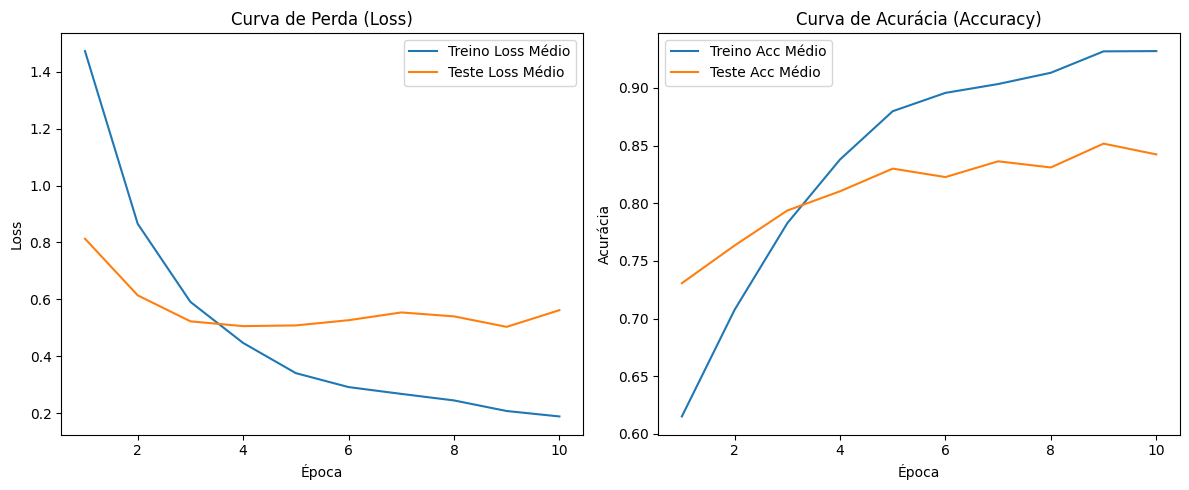

In [ ]:
#Chamada de função para visualizar como foi o treinamento
train_historic_visualization(all_train_losses_contrast_runs, all_train_accuracies_contrast_runs, all_test_losses_contrast_runs, all_test_accuracies_contrast_runs, num_epochs)


### 6. Matriz de Confusão e Relatório de Classificação (ResNet com Contraste)

Avaliando (com contraste): 100%|██████████| 10/10 [00:14<00:00,  1.43s/it]


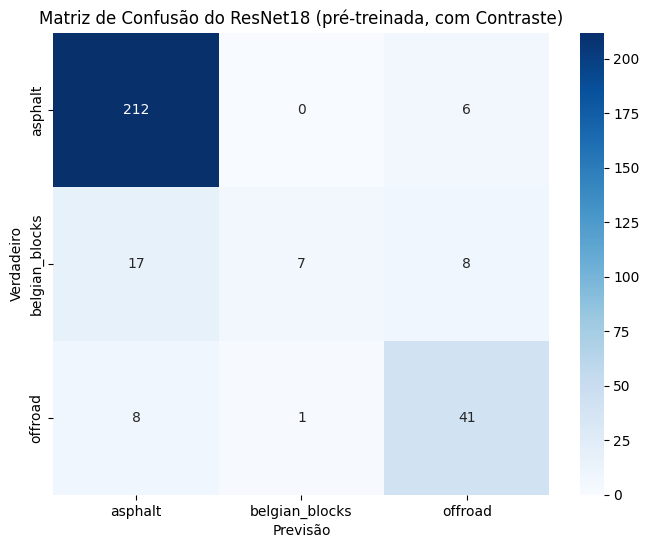


Relatório de Classificação do ResNet18 (pré-treinada, com Contraste):
                precision    recall  f1-score   support

       asphalt       0.89      0.97      0.93       218
belgian_blocks       0.88      0.22      0.35        32
       offroad       0.75      0.82      0.78        50

      accuracy                           0.87       300
     macro avg       0.84      0.67      0.69       300
  weighted avg       0.87      0.87      0.84       300



In [ ]:
_, _, true_labels_final_contrast, predicted_labels_final_contrast = evaluate_model_with_contrast(final_model_contrast, criterion_contrast, test_loader_contrast, device)

conf_matrix_contrast = metrics.confusion_matrix(true_labels_final_contrast, predicted_labels_final_contrast)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_contrast, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.title(f'Matriz de Confusão do ResNet18 (pré-treinada, com Contraste)')
plt.show()

print(f"\nRelatório de Classificação do ResNet18 (pré-treinada, com Contraste):")
print(classification_report(true_labels_final_contrast, predicted_labels_final_contrast, target_names=class_names))

### 7. Criando uma tabela para guardar os resultados dos testes

In [ ]:
df_results_summary_pretrained_contrast = gerar_e_mostrar_tabela_de_resumo(
    true_labels=true_labels_final_contrast,
    predicted_labels=predicted_labels_final_contrast,
    class_names=class_names,
    num_epochs=num_epochs,
    batch_size=batch_size,
    optimizer_obj=optimizer_contrast,
    criterion_obj=criterion_contrast,
    train_losses_history=final_run_train_losses_contrast,
    train_accuracies_history=final_run_train_accuracies_contrast,
    test_losses_history=final_run_test_losses_contrast,
    test_accuracies_history=final_run_test_accuracies_contrast,
    conf_matrix=conf_matrix_contrast,
    model_description="ResNet18 (pré-treinada, com Contraste)"
)


Dicionário de resultados e parâmetros para ResNet18 (pré-treinada, com Contraste) criado com sucesso!
Visualização tabular dos resultados e parâmetros do treinamento (ResNet18 (pré-treinada, com Contraste)):


,Learning Rate,Epochs,Batch Size,Loss Function,Confusion Matrix,Accuracy,Macro Avg Precision,Macro Avg Recall,Macro Avg F1-Score,Weighted Avg Precision,Weighted Avg F1-Score,Weighted Avg Recall
0,0.001,10,32,CrossEntropyLoss,"[[212, 0, 6], [17, 7, 8], [8, 1, 41]]",0.87,0.84,0.67,0.69,0.87,0.84,0.87


##Conclusão das CNNs Pré treinada(sem contraste)

A queda brusca no desempenho da ResNet18 após o balanceamento (Oversampling ou  delegação de peso por classes) pode ser explicada por quatro fatores principais:

1. Robustez do Conhecimento Prévio vs. Viés Estatístico
A ResNet18 pré-treinada no ImageNet funciona como um especialista em texturas. No cenário desbalanceado, ela utiliza essa "sabedoria" para ser conservadora: ela identifica o asfalto com perfeição e só classifica como Belgian Blocks quando tem a máxima confiança (por isso a Precisão de 1.00). O baixo Recall foi uma escolha estatística da rede: na dúvida, ela optava pela classe majoritária para minimizar o erro global(Acurácia total do modelo).

2. Overfitting por Memorização (O "Vício" dos Dados)
Ao realizar o Oversampling, repetimos as mesmas 32 imagens de Belgian Blocks centenas de vezes. Para uma rede profunda e complexa como a ResNet, isso é um convite à memorização.Em vez de aprender o conceito genérico de "pedra", a rede decorou os pixels específicos daquelas poucas fotos. No conjunto de teste, ao encontrar imagens inéditas de paralelepípedos, o modelo falhou por não encontrar exatamente o que memorizou, resultando na queda drástica de desempenho.

3. Instabilidade do Gradiente
Ao realizar o Class Weights a rede entende que ao errar a classificação de uma classe minoritária a rede será punida 10x mais que o erro de uma classe majoritária, por isso a rede fica meio que 'nervosa' e qualquer alteração na imagem pode ser extremamente importante pra classificação da rede de modo que a rede fica bastante sucetível a ruídos

4. Alucinação
Ao forçar o gradiente da rede a focar obsessivamente na classe minoritária, "poluímos" os pesos que antes classificavam o asfalto com perfeição. A rede passou a alucinar: detalhes irrelevantes (como sombras ou reflexos) que apareciam nas fotos repetidas de paralelepípedos passaram a ser interpretados como regras universais. Isso fez com que ela começasse a ver "pedras" onde só havia asfalto liso.

##Conclusão das CNNs treinadas do zero

Diferente do cenário observado na ResNet18, onde a tentativa de balanceamento resultou em uma degradação severa, na CNN treinada do zero (SimpleCNN) o balanceamento mostrou-se praticamente inefetivo. Os resultados entre as versões desbalanceada e balanceada (Oversampling ou Class Weights) foram estatisticamente equivalentes, demonstrando que a reponderação das classes não foi um fator determinante para este modelo.

Por que isso ocorre?
1. Arquitetura Rasa e Alto Viés (High Bias)
Por ser uma rede de poucas camadas, a SimpleCNN possui uma capacidade de aprendizado limitada. Ela é uma rede com alto viés, o que significa que ela é simplista por natureza. Em modelos assim, existe uma resistência inerente ao balanceamento: a rede tende a ignorar nuances e detalhes finos das imagens para focar na média estatística das classes.

2. Saturação do Aprendizado
Diferente da ResNet18, que é profunda e capaz de mapear padrões complexos, a SimpleCNN atinge seu "teto" de performance rapidamente. Ao balancear os dados, tentamos induzir a rede a aprender características específicas da classe minoritária, mas a arquitetura simplesmente não possui parâmetros suficientes para processar essa informação adicional.

3. Generalização "Teimosa" vs. Alucinação
Enquanto a ResNet18 "alucina" ao memorizar ruídos das fotos repetidas (Overfitting), a SimpleCNN se recusa a ser ultra-especialista. Ela atua como uma rede generalista e teimosa: ela prefere manter uma classificação baseada em padrões grosseiros (cores e formas básicas) do que tentar se ajustar a detalhes que ela não tem profundidade para entender.

##Conclusão da CNN Pré treinada e com a inclusão do contraste

No geral, a implementação do contraste como uma feature adicional não se traduziu em ganhos de performance, agindo, na verdade, como um ruído para o modelo.

Piora na performance em Classes Específicas: A classe OFFROAD foi a mais prejudicada, apresentando uma queda na precisão de 0.92 para 0.75, indicando que o contraste excessivo pode ter descaracterizado a assinatura visual orgânica da terra.

Inutilidade para a classe minoritária: Para a classe Belgian Blocks, o impacto foi nulo, mantendo o Recall estagnado em 0.22, o que prova que o contraste não forneceu informações novas que ajudassem na distinção contra o asfalto.

Diagnóstico das Curvas de Aprendizado: Ao analisar os gráficos de Loss e Acurácia, observa-se uma convergência rápida no treino, mas uma estagnação precoce no teste (por volta da 4ª época). Esse distanciamento entre as curvas é um forte indicativo de overfitting incipiente, onde a rede passou a memorizar os produtos gerados pelo contraste em vez de generalizar padrões reais.


##**Conclusões Finais**

Após uma Análise Exploratória de Dados (EDA), percebeu-se que o dataset é extremamente desbalanceado. Trabalhei com a hipótese de que o contraste entre as três classes era bastante distinto, o que poderia auxiliar na classificação. A partir disso, a ideia foi construir testes para encontrar o melhor resultado e verificar se a introdução de uma feature de contraste ajudaria o modelo a identificar melhor o tipo de estrada.

Para os testes, utilizei algoritmos de Redes Neurais Convolucionais (CNN). Optei por comparar dois modelos: uma rede pré-treinada (ResNet18), que teoricamente lidaria melhor com dados desbalanceados via transfer learning, e uma rede treinada do zero, a fim de validar qual abordagem seria mais eficiente para a introdução do contraste.

Utilizei estratégias de balanceamento (Class Weight e Oversampling) em ambas as redes para observar o comportamento dos modelos. Nos testes com a rede pré-treinada (ResNet18), notou-se que, como esperado, ela lidou bem com os dados desbalanceados (sendo o melhor resultado entre todos os experimentos). No entanto, o balanceamento piorou significativamente o desempenho. Isso ocorreu porque, ao balancear, forçamos a rede a focar nas classes minoritárias; com poucos dados, ela tenta aprender padrões muito específicos e termina "desaprendendo" o conhecimento do pré-treinamento, deixando o modelo confuso.

Já nos testes da rede treinada do zero, o resultado foi mediano e o balanceamento não afetou o desempenho final. Os resultados foram extremamente parecidos nos três cenários (desbalanceado, oversampling e class weight). Isso ocorreu pois a arquitetura escolhida era simples demais para o problema, resultando em uma rede "teimosa"(alto viéis) e incapaz de identificar padrões mais complexos.

Por fim, ao aplicar a inclusão do contraste como feature na nossa melhor rede (ResNet18 desbalanceada), o resultado — ao contrário do esperado — foi uma queda de desempenho. O contraste funcionou como um ruído, prejudicando principalmente a classe offroad, que teve a maior queda de acurácia. Já na classe belgian blocks, onde se esperava uma facilitação na identificação, o resultado foi indiferente, com o recall estagnado em 0,22. Portanto, conclui-se que a utilização do contraste como feature adicional foi ineficiente para este modelo.

##Próximos passo

Como discutido nas conclusões, a arquitetura SimpleCNN demonstrou limitações para a complexidade deste problema e o congelamento de parâmetros nos demais modelos restringiu a capacidade de adaptação às variações específicas do dataset. Assim, os próximos passos naturais para a evolução do projeto incluem:

Coleta e Aumento de Dados: A prioridade máxima seria a expansão da base de dados, focando especificamente nas classes minoritárias (belgian blocks e offroad). Acredito que um volume maior de exemplos permitiria que modelos mais profundos aprendessem características morfológicas reais sem cair na armadilha da memorização (overfitting).

Ajuste de Hiperparâmetros (Fine-tuning): Realizar novas baterias de testes com variações de hiperparâmetros — como taxa de aprendizado (learning rate), tamanho do lote (batch size) e funções de otimização — para encontrar o ponto ideal de convergência.

Evolução Arquitetural: Experimentar arquiteturas mais robustas que a SimpleCNN e realizar o descongelamento (unfreezing) gradual das últimas camadas da ResNet18. Isso permitiria que a rede pré-treinada ajustasse seus filtros de textura especificamente para o domínio de tipos de pavimentação.

##Como a IA foi utilizada no projeto

No geral, utilizei a IA para a construção dos códigos. Logicamente, eu analisava o que era gerado e fazia as alterações necessárias, principalmente porque a IA repetia muito os códigos. Ou seja, funcionou bem no estilo vibe coding. Além disso, usei a IA como mentor, pedindo sua opinião sobre minhas análises críticas para verificar se eu estava sendo coeso com os testes realizados. Também usei ela para organizar meus textos, eu escrevia as ideias brutas e pedia para a IA deixá-las mais organizadas e fáceis de ler. Esses foram os meios pelos quais usei a inteligência artificial no projeto.

##Dificuldades no projeto

No geral, a maior dificuldade do projeto foi a questão do tempo. Devido ao prazo limitado, precisei arquitetar o plano do projeto de maneira muito rápida, o que impossibilitou a variação exaustiva de hiperparâmetros. Outro obstáculo significativo foi a limitação de uso de GPU no Google Colab; a alta exigência computacional dos modelos muitas vezes excedia a cota disponível. Isso me forçou, em diversas ocasiões, a interromper treinamentos ou alternar entre contas do Google para garantir o acesso a GPU e não perder prazos. Cada treinamento de rede levava cerca de 55 minutos, mesmo após eu ter reduzido o número do loop(usado para dar mais credibilidade ao resultado, visto que uma rede neural é um algoritmo não determinístico) de 30 para 10, visto que o tempo original de 3 horas por execução tornava o fluxo de trabalho inviável dentro do cronograma estabelecido.